In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import tifffile
from einops import rearrange
from ome_types import OME, from_tiff, from_xml
from scipy.ndimage import binary_fill_holes, binary_erosion, binary_dilation
from skimage.segmentation import expand_labels
from skimage.morphology import label
from scipy import sparse


/home/estorrs/.local/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/miniconda/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## utils

###### input data

In [2]:
def process_adata(adata):
    sc.pp.filter_cells(adata, min_counts=10)
    sc.pp.filter_genes(adata, min_cells=5)
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    return adata

def adata_from_xenium(filepath, scaler=.1, normalize=False, transcripts=False, base=np.e):
    adata = sc.read_10x_h5(
        filename=os.path.join(filepath, 'cell_feature_matrix.h5')
    )

    df = pd.read_csv(
        os.path.join(filepath, 'cells.csv.gz')
    )
    df = df.set_index('cell_id')
    adata.obs = df.copy()
    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy().astype(int)

    if os.path.exists(os.path.join(filepath, 'morphology_focus.ome.tif')):
        fp = os.path.join(filepath, 'morphology_focus.ome.tif')
        dim_order = 'w c'
    elif os.path.exists(os.path.join(filepath, 'morphology.ome.tif')):
        fp = os.path.join(filepath, 'morphology_focus', 'morphology_focus_0000.ome.tif')
        dim_order = 'c h w'
    else:
        raise RuntimeError(f'Could not find morphology.ome.tif')

    adata.uns['ome'] = from_tiff(fp).model_dump_json()
    adata = process_adata(adata)

    return adata

def tile_xenium(adata, target_size=None, tile_size=10, transcripts=None, genes=None):
    if target_size is None:
        model = json.loads(adata.uns['ome'])
        h, w = model['images'][0]['pixels']['size_y'], model['images'][0]['pixels']['size_x']
        upp = model['images'][0]['pixels']['physical_size_y']
        target_size = (int(h * upp), int(w * upp))
    
    if transcripts is None:
        if genes is not None:
            adata = adata[:, genes]

        adata.obs['grid_name'] = [f'{x // tile_size}_{y // tile_size}'
                                  for x, y in adata.obsm['spatial'].astype(int)]
        df = pd.DataFrame(
            data=adata.X,
            columns=adata.var.index.to_list(),
            index=adata.obs.index.to_list()
        )
        df['grid_name'] = adata.obs['grid_name'].to_list()
        df = df.groupby('grid_name').sum()    
    else:
        transcripts['grid_name'] = [
            f'{x // tile_size}_{y // tile_size}'
            for x, y in transcripts[['x_location', 'y_location']].values.astype(int)]

        df = transcripts[['feature_name', 'grid_name', 'transcript_id']].groupby(['feature_name', 'grid_name']).count()
        df = df.reset_index()
        df = df.pivot_table(index=['grid_name'], columns=['feature_name'])
        df = df.replace(np.nan, 0)
        df.columns = [c for _, c in list(df.columns)]
        df = df[[c for c in df.columns if 'Codeword' not in c and 'NegControl' not in c]] # get rid of weird feature names

    img = np.zeros((target_size[0] // tile_size + 1, target_size[1] // tile_size + 1, df.shape[1]))
    for name, row in df.iterrows():
        x, y = [int(x) for x in name.split('_')]
        img[y, x] = row.values

    if transcripts is None:
        return img
    else:
        return img, list(df.columns)

def tile_cosmx(adata, target_size=None, tile_size=10, transcripts=None, genes=None):
    if target_size is None:
        target_size = (int(adata.uns['ome']['physical_size_y']), int(adata.uns['ome']['physical_size_x']))

    transcripts['grid_name'] = [
        f'{x // tile_size}_{y // tile_size}'
        for x, y in transcripts[['x_location', 'y_location']].values.astype(int)]

    df = transcripts[['feature_name', 'grid_name', 'transcript_id']].groupby(['feature_name', 'grid_name']).count()
    df = df.reset_index()
    df = df.pivot_table(index=['grid_name'], columns=['feature_name'])
    df = df.replace(np.nan, 0)
    df.columns = [c for _, c in list(df.columns)]
    df = df[[c for c in df.columns if 'Codeword' not in c and 'NegControl' not in c]] # get rid of weird feature names

    img = np.zeros((target_size[0] // tile_size + 1, target_size[1] // tile_size + 1, df.shape[1]))
    
    print(img.shape)

    for name, row in df.iterrows():
        x, y = [int(x) for x in name.split('_')]
        img[y, x] = row.values

    return img, list(df.columns)


from scipy import sparse
def visiumhd_to_tiled(adata, tile_size: int, channels: list[str]) -> np.ndarray:
    """
    Converts Visium-HD AnnData object into (C, H, W) image by spatially tiling total counts.

    Parameters:
        adata     : AnnData object with `.X` (sparse counts), `.obs[['x_location', 'y_location']]`, and `.var`
        tile_size : Size of spatial tile in same units as x/y_location
        channels  : List of gene names (adata.var.index) to include as image channels

    Returns:
        np.ndarray of shape (C, H, W) with summed counts per tile
    """
    # Get spatial coordinates
    x = adata.obs['x_location'].values
    y = adata.obs['y_location'].values

    # Bin coordinates
    x_bins = (x / tile_size).astype(int)
    y_bins = (y / tile_size).astype(int)

    # Offset so min bin is at (0, 0)
    x_bins -= x_bins.min()
    y_bins -= y_bins.min()

    W = x_bins.max() + 1
    H = y_bins.max() + 1
    C = len(channels)

    # Output image array
    image = np.zeros((C, H, W), dtype=np.float32)

    # Map channel names to var indices
    channel_idx = [adata.var.index.get_loc(c) for c in channels]

    # Pull counts only for desired genes
    X_sub = adata.X[:, channel_idx]  # shape: (n_cells, C)

    # Ensure CSR for row access
    if not sparse.isspmatrix_csr(X_sub):
        X_sub = X_sub.tocsr()

    # Efficient loop over channels
    for c in range(C):
        col = X_sub[:, c].toarray().flatten()  # counts for gene c
        # Use bincount for fast 2D binning via 1D encoding
        flat_idx = y_bins * W + x_bins
        summed = np.bincount(flat_idx, weights=col, minlength=H * W)
        image[c] = summed.reshape(H, W)

    return image


In [3]:
from scipy.ndimage import gaussian_filter
from skimage.morphology import label, remove_small_objects

def process_and_save_mask(mask):
    mask = binary_fill_holes(mask)
    mask = remove_small_objects(mask.astype(bool), min_size=10, connectivity=1)
    
    erroded = binary_erosion(mask)
    
    
    labeled = label(erroded)
    labels, counts = np.unique(labeled, return_counts=True)

    ring_labels = expand_labels(labeled, distance=2)
    tme_labels = expand_labels(labeled, distance=4)
#     tme_labels[mask] = 0
    tme_labels[ring_labels > 0] = 0
    ring_labels[labeled > 0] = 0
    
    return labeled, ring_labels, tme_labels


###### transcript counting

In [4]:
from __future__ import annotations

def count_genes_in_regions(
    label_img: np.ndarray,
    spots: pd.DataFrame,
    *,
    per_gene: bool = False,
    aggregate: str = "unique",
) -> pd.DataFrame:
    """"""
    required = {"gene", "x", "y"}
    if not required.issubset(spots.columns):
        raise ValueError(f"`spots` must contain columns {sorted(required)}")

    x = spots["x"].to_numpy(np.int64)
    y = spots["y"].to_numpy(np.int64)

    h, w = label_img.shape
    
    
    if (x < 0).any() or (y < 0).any() or (x >= w).any() or (y >= h).any():
        raise ValueError("Some x/y coordinates fall outside label_img bounds")

    # Look up the region ID for every spot in one call
    region_ids = label_img[y, x]

    # Keep only spots that overlap a region (>0)
    mask = region_ids > 0
    if not mask.any():
        return pd.DataFrame()

    df = spots.loc[mask].assign(region_id=region_ids[mask])

    if per_gene:
        # Region × gene matrix (sparse-friendly if converted via .sparse)
        return (
            df.groupby(["region_id", "gene"])
              .size()
              .unstack(fill_value=0)
              .sort_index()
        )

    if aggregate == "unique":
        return (
            df.groupby("region_id")["gene"]
              .nunique()
              .rename("unique_gene_count")
              .to_frame()
        )

    if aggregate == "transcript":
        return (
            df.groupby("region_id")
              .size()
              .rename("transcript_count")
              .to_frame()
        )

    raise ValueError("aggregate must be 'unique' or 'transcript'")
    
from scipy import sparse
from anndata import AnnData

def aggregate_counts_by_region(adata: AnnData, label_image: np.ndarray, scale: float) -> pd.DataFrame:
    """
    Aggregate gene expression counts from an AnnData object into labeled regions of an image.

    Parameters:
        adata        : AnnData object with .X (counts), and obs['x_location'], obs['y_location']
        label_image  : 2D numpy array where each pixel has an integer label (0 = background)
        scale        : float scale factor to align coordinates with label_image (e.g., 1 micron = 1 pixel)

    Returns:
        pd.DataFrame: rows = region labels, columns = gene names, values = total counts per region
    """

    # Get scaled pixel locations
    x = (adata.obs['x_location'].values / scale).astype(int)
    y = (adata.obs['y_location'].values / scale).astype(int)

    # Mask to filter valid coordinates inside the label image
    valid_mask = (
        (x >= 0) & (x < label_image.shape[1]) &
        (y >= 0) & (y < label_image.shape[0])
    )

    x = x[valid_mask]
    y = y[valid_mask]
    regions = label_image[y, x]

    # Get non-background only (label 0 is background)
    region_mask = regions > 0
    regions = regions[region_mask]
    row_indices = np.where(valid_mask)[0][region_mask]

    # Pull only valid cell rows from count matrix
    X = adata.X
    if sparse.issparse(X):
        X = X.tocsr()
        X_sub = X[row_indices]
    else:
        X_sub = X[row_indices, :]

    # Create output: rows = region, columns = genes
    unique_regions = np.unique(regions)
    gene_names = adata.var.index.to_numpy()
    out = np.zeros((len(unique_regions), X.shape[1]), dtype=np.float64)

    region_to_idx = {region: i for i, region in enumerate(unique_regions)}
    
    for i, region in enumerate(regions):
        region_idx = region_to_idx[region]
        row = X_sub[i]
        if sparse.issparse(row):
            row = row.toarray().flatten()
        out[region_idx] += row

    # Return as DataFrame
    df = pd.DataFrame(out, index=unique_regions, columns=gene_names)
    df.index.name = 'region_label'
    return df

###### correlation calcs

In [5]:

def correlate_to_target_per_sample(
    df: pd.DataFrame,
    target_gene: str,
    *,
    sample_col: str = "sid",
    scale: float = 1e4,
) -> pd.DataFrame:
    """
    Pearson-correlate *target_gene* with every other gene inside each sample.

    Normalisation pipeline (per sample)
    -----------------------------------
    1. **Sample/library normalisation**
           cp10k = counts / Σ_all_regions&genes(counts) * 10 000
    2. **Row (region) normalisation**
           row_norm = cp10k / row_sum(cp10k)

       • Rows with a 0 or NaN sum stay NaN.
       • A gene that is entirely NaN within a sample yields NaN correlation.

    Returns
    -------
    DataFrame  (index = sample IDs, columns = genes ≠ *target_gene*)
    """
    if target_gene not in df.columns:
        raise KeyError(f"{target_gene!r} not found in dataframe columns")

    gene_cols = df.columns.drop(sample_col)
    results: list[pd.Series] = []

    for sid, g in df.groupby(sample_col, sort=False):
        arr = g[gene_cols].to_numpy(dtype=float, copy=False)

        total = np.nansum(arr)
        if total == 0 or np.isnan(total):
            # no usable data in this sample
            results.append(
                pd.Series(np.nan, index=gene_cols.drop(target_gene), name=sid)
            )
            continue

        arr *= scale / total

        row_sum = np.nansum(arr, axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            arr = np.divide(
                arr,
                row_sum,
                out=np.full_like(arr, np.nan),
                where=row_sum != 0,
            )

        expr = pd.DataFrame(arr, columns=gene_cols, index=g.index)
#         corr = expr.corrwith(expr[target_gene], axis=0, method="pearson")
        corr = expr.corrwith(expr[target_gene], axis=0, method="spearman")
        corr = corr.drop(target_gene)          # exclude self-correlation
        results.append(corr.rename(sid))

    return pd.DataFrame(results)


## xenium processing

In [313]:
output_dir = Path('../data/spatial/regions/xenium')

In [314]:
meta = pd.read_csv(
    '../data/spatial/metadata/2d_data_tracking_xenium.csv',
    sep=','
)
meta = meta[['Section_ID_clean', 'Block_ID', 'Site', 'sample_run_name', 'storage1_path']]
meta

,Section_ID_clean,Block_ID,Site,sample_run_name,storage1_path
0,SP003Z1-Fp1Us1_1,S18-15142-B17,Prostate,output-XETG00122__0011120__S18-15142Fp1Us1_1__...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
1,SP017Z1-Fp1B27Us1_17,S18-9906-B27,Prostate,output-XETG00122__0010784__S18-9906-B27Us1_17Q...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
2,SP017Z1-Fp1B27Us1_2,S18-9906-B27,Prostate,output-XETG00122__0010784__S18-9906-B27Us1_2Q1...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
3,SP017Z1-Fp1B27Us1_24,S18-9906-B27,Prostate,output-XETG00122__0010787__S18-9906-B27Us1_24Q...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
4,SP017Z1-Fp1B27Us1_9,S18-9906-B27,Prostate,output-XETG00122__0010787__S18-9906-B27Us1_9Q1...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
...,...,...,...,...,...
70,1607059U1,1607059,Breast,output-XETG00523__0037628__1607059U1__20250124...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
71,HT944B1-S2H2bFpU1,HT944B1-S2H2bFp,Breast,output-XETG00523__0037640__HT944B1-S2H2bFpU1__...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
72,SP048Z1-Fp1C27U2,S18-5929-C27,Prostate,output-XETG00122__0033872__S18-5929-C27U2__202...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...
73,SP051Z1-Fp1F1U2,S20-23195-F1,Prostate,output-XETG00122__0033872__S20-23195-F1U2__202...,/storage1/fs1/dinglab/Active/Primary/HTAN.Imag...


In [315]:
for i, row in meta.iterrows():
    sid = row['Section_ID_clean']
    print(i, sid)
    path = Path(row['storage1_path'])
    try:
        adata = adata_from_xenium(path)
        transcripts = pd.read_parquet(path / 'transcripts.parquet')
        keep = ['EPCAM']
        transcripts = transcripts[[x in keep for x in transcripts['feature_name']]]
    
        img, genes = tile_xenium(adata, tile_size=10, transcripts=transcripts)
        np.save(output_dir / f'{sid}_epcam_tiled.npy', img)
#         json.dump(genes, open(output_dir / f'{sid}_tiled_genes.json', 'w'))
        adata.write_h5ad(output_dir / f'{sid}.h5ad')
    except Exception as e:
        print(f'FAILED {sid}: {path}')
        print(e)


0 SP003Z1-Fp1Us1_1
1 SP017Z1-Fp1B27Us1_17
2 SP017Z1-Fp1B27Us1_2
3 SP017Z1-Fp1B27Us1_24
4 SP017Z1-Fp1B27Us1_9
5 SP003Z1-Fp1A15Us1_1
6 SP004Z1-Fp1B17Us2_1
7 SP005Z1-Fp1A25Us1_1
8 SP006Z1-Fp1C8Us1_1
9 SP008Z1-Fp1F15U1
10 SP009Z1-Fp1B14U1
11 SP012Z1-Fp1-A2U3
12 SP015Z1-Fp1A1U3
13 SP006Z1-Fp1C8Us2_1
14 SP006Z1-Fp1C8Us2_12
15 SP006Z1-Fp1C8Us2_18
16 SP006Z1-Fp1C8Us2_20
17 SP006Z1-Fp1C8Us2_5
18 SP006Z1-Fp1C8Us2_7
19 HT814Z1-S1H1Fp1Us1_3
20 HT817Z1-S1H1Fp1Us1_2
21 SP007Z1-Fp1A10Us2_1
22 HT832Z1-S1H1Fp1U1
23 SP016Z1-Fp1B28U1
24 HT849Z1-S1H2Fp1U1
25 HT852Z1-S1H1Fp1U1
26 SP011Z1-Fp1-A15U1
27 SP014Z1-Fp1A29U1
28 HT891Z1-S2H3Fp1U1
29 HT891Z1-S2H3Fp1U21
30 HT891Z1-S2H3Fp1U32
31 HT891Z1-S2H3Fp1U44
32 HT891Z1-S2H3Fp1U59
33 HT891Z1-S2H3Fp1U69
34 HT891Z1-S2H3Fp1U104
35 HT891Z1-S2H3Fp1U81
36 HT891Z1-S2H3Fp1U94
37 HT913Z1-S2H1Fp1U101
38 HT913Z1-S2H1Fp1U33
39 HT913Z1-S2H1Fp1U34
40 HT913Z1-S2H1Fp1U35
41 HT913Z1-S2H1Fp1U61
42 HT913Z1-S2H1Fp1U81
43 HT913Z1-S2H1Fp1U1
44 HT913Z1-S2H1Fp1U11
45 HT913Z1-S2H1Fp1U21


In [316]:
fps = [output_dir / p for p in os.listdir(output_dir) if 'epcam_tiled.npy' in p]
fps

[PosixPath('../data/spatial/regions/xenium/HT206B1-H2L1Us1_9_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/HT206B1-H2L1Us1_17_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/SP005Z1-Fp1A25Us1_1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/HT591B1-S1H1Fp1Us1_1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/SP007Z1-Fp1A10Us2_1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/SP006Z1-Fp1C8Us2_7_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/SP006Z1-Fp1C8Us2_12_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/HT891Z1-S2H3Fp1U94_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/HT832Z1-S1H1Fp1U1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/HT704B1-S1H3Fp1U41_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/SP051Z1-Fp1F1U2_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/xenium/SP048Z1-Fp1C27U2_epcam_tiled.npy'),
 PosixPath('../data/spatial/re

In [317]:
for fp in fps:
    sid = str(fp).split('/')[-1].replace('_epcam_tiled.npy', '')
    print(sid)
    x = np.load(fp)[..., 0]

    norm = x / x.std()
    mask = norm > 1
    
    labeled, ring_labels, tme_labels = process_and_save_mask(mask)
    
    np.save(output_dir / f'{sid}_epi_region_labeled.npy', labeled)
    np.save(output_dir / f'{sid}_epi_ring_labeled.npy', ring_labels)
    np.save(output_dir / f'{sid}_epi_tme_labeled.npy', tme_labels)

HT206B1-H2L1Us1_9
HT206B1-H2L1Us1_17
SP005Z1-Fp1A25Us1_1
HT591B1-S1H1Fp1Us1_1
SP007Z1-Fp1A10Us2_1
SP006Z1-Fp1C8Us2_7
SP006Z1-Fp1C8Us2_12
HT891Z1-S2H3Fp1U94
HT832Z1-S1H1Fp1U1
HT704B1-S1H3Fp1U41
SP051Z1-Fp1F1U2
SP048Z1-Fp1C27U2
HT832Z1-S1H1Fp1U2
SP006Z1-Fp1C8Us2_1
SP050Z1-Fp1A1U2
HT913Z1-S2H1Fp1U33
1654977AU1
HT1011Z1-S1H3Fp1U1
SP015Z1-Fp1A1U3
SP017Z1-Fp1B27Us1_24
SP012Z1-Fp1-A2U3
HT913Z1-S1H1Fp1U1
HT913Z1-S2H1Fp1U61
HT727B1-S1H4Fp1U1
HT704B1-S1H3Fp1U1
SP048Z1-Fp1C27U1
HT913Z1-S1H1Fp1U8
HT849Z1-S1H2Fp1U1
HT913Z1-S2H1Fp1U21
SP017Z1-Fp1B27Us1_2
HT206B1-H2L1Us1_24
HT817Z1-S1H1Fp1Us1_2
SP017Z1-Fp1B27Us1_17
SP011Z1-Fp1-A15U1
HT704B1-S1H3Fp1U26
HT913Z1-S1H1Fp1U11
HT891Z1-S2H3Fp1U69
SP006Z1-Fp1C8Us2_5
SP017Z1-Fp1B27Us1_9
SP014Z1-Fp1A29U1
1607059U1
HT814Z1-S1H1Fp1Us1_3
SP006Z1-Fp1C8Us1_1
HT704B1-S1H3Fp1U50
HT206B1-H2L1Us1_1
HT944B1-S2H2bFpU1
HT891Z1-S2H3Fp1U32
SP006Z1-Fp1C8Us2_20
SP008Z1-Fp1F15U1
HT704B1-S1H3Fp1U33
HT206B1-H2L1Us1_8
HT891Z1-S2H3Fp1U59
HT891Z1-S2H3Fp1U81
1661918aU1
HT891Z1-S2H3Fp

In [318]:
for i, row in meta.iterrows():
    sid = row['Section_ID_clean']
    print(sid)

    region_fp = output_dir / f'{sid}_epi_region_labeled.npy'
    transcripts_fp = Path(row['storage1_path']) / 'transcripts.parquet'
    
    transcripts = pd.read_parquet(transcripts_fp)
    transcripts = transcripts[['feature_name', 'x_location', 'y_location']]
    transcripts.columns = ['gene', 'x', 'y']
    transcripts['x'] /= 10
    transcripts['y'] /= 10

    mapping = {
        'region': output_dir / f'{sid}_epi_region_labeled.npy',
        'boundary': output_dir / f'{sid}_epi_ring_labeled.npy',
        'tme': output_dir / f'{sid}_epi_tme_labeled.npy',
    }
    
    for k, fp in mapping.items():
        labeled = np.load(fp)
        df = count_genes_in_regions(labeled, transcripts, per_gene=True)
        df.to_csv(output_dir / f'{sid}_{k}_counts.txt', sep='\t')

SP003Z1-Fp1Us1_1
SP017Z1-Fp1B27Us1_17
SP017Z1-Fp1B27Us1_2
SP017Z1-Fp1B27Us1_24
SP017Z1-Fp1B27Us1_9
SP003Z1-Fp1A15Us1_1
SP004Z1-Fp1B17Us2_1
SP005Z1-Fp1A25Us1_1
SP006Z1-Fp1C8Us1_1
SP008Z1-Fp1F15U1
SP009Z1-Fp1B14U1
SP012Z1-Fp1-A2U3
SP015Z1-Fp1A1U3
SP006Z1-Fp1C8Us2_1
SP006Z1-Fp1C8Us2_12
SP006Z1-Fp1C8Us2_18
SP006Z1-Fp1C8Us2_20
SP006Z1-Fp1C8Us2_5
SP006Z1-Fp1C8Us2_7
HT814Z1-S1H1Fp1Us1_3
HT817Z1-S1H1Fp1Us1_2
SP007Z1-Fp1A10Us2_1
HT832Z1-S1H1Fp1U1
SP016Z1-Fp1B28U1
HT849Z1-S1H2Fp1U1
HT852Z1-S1H1Fp1U1
SP011Z1-Fp1-A15U1
SP014Z1-Fp1A29U1
HT891Z1-S2H3Fp1U1
HT891Z1-S2H3Fp1U21
HT891Z1-S2H3Fp1U32
HT891Z1-S2H3Fp1U44
HT891Z1-S2H3Fp1U59
HT891Z1-S2H3Fp1U69
HT891Z1-S2H3Fp1U104
HT891Z1-S2H3Fp1U81
HT891Z1-S2H3Fp1U94
HT913Z1-S2H1Fp1U101
HT913Z1-S2H1Fp1U33
HT913Z1-S2H1Fp1U34
HT913Z1-S2H1Fp1U35
HT913Z1-S2H1Fp1U61
HT913Z1-S2H1Fp1U81
HT913Z1-S2H1Fp1U1
HT913Z1-S2H1Fp1U11
HT913Z1-S2H1Fp1U21
HT913Z1-S1H1Fp1U1
HT913Z1-S1H1Fp1U11
HT913Z1-S1H1Fp1U8
SP048Z1-Fp1C27U1
SP016Z1-Fp1B28U2
HT832Z1-S1H1Fp1U2
HT1011Z1-S1H3Fp1U1
HT

In [319]:
fps = [output_dir / p for p in os.listdir(output_dir) if 'region_counts.txt' in p]
fps

[PosixPath('../data/spatial/regions/xenium/HT1011Z1-S1H3Fp1U1_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/HT704B1-S1H3Fp1U17_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/SP006Z1-Fp1C8Us2_7_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/SP006Z1-Fp1C8Us2_1_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/HT206B1-H2L1Us1_9_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/HT913Z1-S2H1Fp1U35_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/HT852Z1-S1H1Fp1U1_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/SP007Z1-Fp1A10Us2_1_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/SP003Z1-Fp1Us1_1_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/HT913Z1-S2H1Fp1U61_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/HT913Z1-S1H1Fp1U1_region_counts.txt'),
 PosixPath('../data/spatial/regions/xenium/HT206B1-H2L1Us1_15_region_counts.txt'),
 PosixPa

In [320]:
combined = {
    'region': None,
    'boundary': None,
    'tme': None
}

for i, row in meta.iterrows():
    sid = row['Section_ID_clean']
    print(sid)
    
    mapping = {
        'region': output_dir / f'{sid}_region_counts.txt',
        'boundary': output_dir / f'{sid}_boundary_counts.txt',
        'tme': output_dir / f'{sid}_tme_counts.txt',
    }
    
    for k, fp in mapping.items():
        df = pd.read_csv(fp, sep='\t')
        df = df.set_index('region_id')
        df.index = [f'{sid}_{x}' for x in df.index.to_list()]
        
        if combined[k] is None:
            combined[k] = df
        else:
            combined[k] = pd.concat((combined[k], df))
        print(combined[k].shape)

SP003Z1-Fp1Us1_1
(3929, 541)
(3929, 541)
(3927, 541)
SP017Z1-Fp1B27Us1_17
(5896, 541)
(5896, 541)
(5894, 541)
SP017Z1-Fp1B27Us1_2
(7810, 541)
(7810, 541)
(7808, 541)
SP017Z1-Fp1B27Us1_24
(9951, 541)
(9951, 541)
(9949, 541)
SP017Z1-Fp1B27Us1_9
(12317, 541)
(12317, 541)
(12310, 541)
SP003Z1-Fp1A15Us1_1
(15755, 641)
(15755, 641)
(15746, 641)
SP004Z1-Fp1B17Us2_1
(18717, 641)
(18717, 641)
(18707, 641)
SP005Z1-Fp1A25Us1_1
(20104, 641)
(20104, 641)
(20093, 641)
SP006Z1-Fp1C8Us1_1
(21325, 641)
(21325, 641)
(21314, 641)
SP008Z1-Fp1F15U1
(23763, 641)
(23763, 641)
(23751, 641)
SP009Z1-Fp1B14U1
(24293, 641)
(24293, 641)
(24281, 641)
SP012Z1-Fp1-A2U3
(24516, 641)
(24516, 641)
(24504, 641)
SP015Z1-Fp1A1U3
(24693, 641)
(24693, 641)
(24681, 641)
SP006Z1-Fp1C8Us2_1
(26187, 641)
(26187, 641)
(26175, 641)
SP006Z1-Fp1C8Us2_12
(27515, 641)
(27515, 641)
(27503, 641)
SP006Z1-Fp1C8Us2_18
(28936, 641)
(28936, 641)
(28924, 641)
SP006Z1-Fp1C8Us2_20
(30094, 641)
(30094, 641)
(30081, 641)
SP006Z1-Fp1C8Us2_5
(31539

In [321]:
for k, v in combined.items():
    v.index.name = 'region_id'
    v.to_parquet(output_dir / f'combined_counts_{k}.parquet')

In [322]:
basal = pd.read_parquet(output_dir / f'combined_counts_boundary.parquet',
                        columns=['KRT5', 'KRT14', 'KRT15', 'LAMB3', 'ACTA2'])

values = np.full((basal.shape[0],), np.nan, dtype=basal.values.dtype)
for c in basal.columns:
    mask = pd.isnull(values)
    values[mask] = basal[c][mask]



case_meta = pd.read_csv('/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/data/spatial/metadata/2d_data_tracking_metadata.csv')
to_tnbc = {x:y for x, y in case_meta[['sid', 'is_tnbc']].values}

basal['sid'] = ['_'.join(x.split('_')[:-1]) for x in basal.index.to_list()]
basal['is_tnbc'] = [to_tnbc[sid] for sid in basal['sid']]

values[basal['is_tnbc']] = basal[basal['is_tnbc']]['ACTA2']

basal['basal'] = values

basal

,KRT5,KRT14,KRT15,LAMB3,ACTA2,sid,is_tnbc,basal
region_id,,,,,,,,
SP003Z1-Fp1Us1_1_1,NaN,NaN,NaN,NaN,7786.0,SP003Z1-Fp1Us1_1,False,7786.0
SP003Z1-Fp1Us1_1_2,NaN,NaN,NaN,NaN,9.0,SP003Z1-Fp1Us1_1,False,9.0
SP003Z1-Fp1Us1_1_3,NaN,NaN,NaN,NaN,0.0,SP003Z1-Fp1Us1_1,False,0.0
SP003Z1-Fp1Us1_1_4,NaN,NaN,NaN,NaN,43.0,SP003Z1-Fp1Us1_1,False,43.0
SP003Z1-Fp1Us1_1_5,NaN,NaN,NaN,NaN,10.0,SP003Z1-Fp1Us1_1,False,10.0
...,...,...,...,...,...,...,...,...
SP050Z1-Fp1A1U2_404,0.0,0.0,NaN,NaN,0.0,SP050Z1-Fp1A1U2,False,0.0
SP050Z1-Fp1A1U2_405,2.0,0.0,NaN,NaN,31.0,SP050Z1-Fp1A1U2,False,2.0
SP050Z1-Fp1A1U2_406,0.0,0.0,NaN,NaN,0.0,SP050Z1-Fp1A1U2,False,0.0


In [323]:
df = pd.read_parquet(output_dir / f'combined_counts_region.parquet')
df.insert(0, 'sid', ['_'.join(x.split('_')[:-1]) for x in df.index.to_list()])
df['basal_target'] = basal['basal']
results = correlate_to_target_per_sample(df, target_gene='basal_target')
results.index.name = 'sid'
results.to_csv(output_dir / 'correlations_regions.txt', sep='\t')
results

,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,ADGRL4,ADH1C,...,RBP1,RHOD,ROBO1,SCGB1A1,SCGB3A1,SETD7,TGFBI,TIMP1,TXNIP,pks+.Escherichia.coli.clbB
sid,,,,,,,,,,,,,,,,,,,,,
SP003Z1-Fp1Us1_1,-0.197883,-0.183497,-0.179374,-0.020383,-0.027058,-0.198461,-0.145785,-0.218893,-0.192883,-0.178960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_17,-0.102696,-0.190351,-0.140126,0.079098,0.041352,-0.217812,-0.193557,-0.159158,-0.195172,-0.184766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_2,-0.093740,-0.173833,-0.156175,0.039747,0.027729,-0.208459,-0.199149,-0.172355,-0.160801,-0.195438,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_24,-0.122278,-0.137613,-0.136617,0.130806,0.030467,-0.225844,-0.120561,-0.114040,-0.180025,-0.147761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_9,-0.205578,-0.257688,-0.231413,0.056632,-0.004522,-0.274171,-0.232630,-0.256846,-0.290187,-0.272649,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1607059U1,NaN,-0.321180,NaN,0.215417,NaN,-0.427342,-0.314387,-0.389879,-0.316282,NaN,...,-0.156693,-0.138478,-0.372301,-0.313340,-0.343372,-0.349247,-0.441495,-0.355218,-0.194383,-0.355942
HT944B1-S2H2bFpU1,NaN,-0.246161,NaN,0.187639,NaN,-0.084923,-0.396548,-0.203149,-0.337597,NaN,...,-0.022654,0.074488,-0.172070,-0.240306,-0.200573,-0.208145,0.186819,0.230816,0.400836,-0.161316
SP048Z1-Fp1C27U2,0.090842,0.027688,0.037362,-0.099453,0.052199,0.210076,0.074787,0.061859,-0.024952,0.030085,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [324]:
df = pd.read_parquet(output_dir / f'combined_counts_tme.parquet')
df.insert(0, 'sid', ['_'.join(x.split('_')[:-1]) for x in df.index.to_list()])
df['basal_target'] = basal['basal']
results = correlate_to_target_per_sample(df, target_gene='basal_target')
results.index.name = 'sid'
results.to_csv(output_dir / 'correlations_tme.txt', sep='\t')
results

,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,ADGRL4,ADH1C,...,RBP1,RHOD,ROBO1,SCGB1A1,SCGB3A1,SETD7,TGFBI,TIMP1,TXNIP,pks+.Escherichia.coli.clbB
sid,,,,,,,,,,,,,,,,,,,,,
SP003Z1-Fp1Us1_1,-0.023055,-0.053053,-0.003162,0.475458,0.397118,-0.020684,0.094543,-0.022054,0.027648,-0.077885,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_17,0.010149,0.004386,-0.035771,0.540147,0.497428,0.017201,0.193386,-0.037121,-0.044233,0.023963,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_2,-0.002647,-0.029040,-0.007827,0.517099,0.486559,-0.031559,0.147071,-0.022955,-0.037746,-0.002040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_24,0.020536,-0.011239,-0.001353,0.533464,0.483950,-0.055720,0.151268,0.012797,-0.041678,-0.004492,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1-Fp1B27Us1_9,0.028392,0.017253,-0.032356,0.420714,0.397135,-0.055225,0.053364,0.030506,-0.076143,0.047952,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1607059U1,NaN,0.166212,NaN,0.300610,NaN,-0.007702,0.007059,-0.090722,-0.086555,NaN,...,-0.053218,-0.092535,0.021032,0.015426,0.000817,0.138803,0.078765,-0.075522,0.112117,0.166234
HT944B1-S2H2bFpU1,NaN,0.044262,NaN,0.563884,NaN,-0.024436,0.067766,-0.062088,-0.017073,NaN,...,0.281616,0.400614,0.106096,-0.019272,0.037232,-0.037546,-0.220155,0.383823,0.113758,0.057053
SP048Z1-Fp1C27U2,0.205420,0.184014,0.026761,-0.094301,-0.026101,0.186265,0.016081,0.104635,-0.009548,0.086150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Xenium Analysis

In [361]:
# disease = 'prostate'
disease = 'breast'

# mask_type = 'region'
mask_type = 'tme'

sid_to_tissue = {x:y for x, y in case_meta[['sid', 'tissue']].values}

In [362]:
ext = 's' if mask_type == 'region' else ''
sample_corrs = pd.read_csv(output_dir / f'correlations_{mask_type}{ext}.txt', sep='\t', index_col=0)
sample_corrs = sample_corrs[[sid_to_tissue[k] == disease if disease != 'all' else True
                           for k in sample_corrs.index.to_list()]]

case_corrs = sample_corrs.copy()
case_corrs.insert(0,'case', [x.split('-')[0].split('_')[0].replace('U1', '') for x in case_corrs.index.to_list()])
case_corrs = case_corrs.groupby('case').mean()
case_corrs.to_csv(output_dir / f'correlations_{mask_type}s_caselevel_{disease}.txt', sep='\t')
sample_corrs.to_csv(output_dir / f'correlations_{mask_type}s_samplelevel_{disease}.txt', sep='\t')

case_corrs

,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,ADGRL4,ADH1C,...,RBP1,RHOD,ROBO1,SCGB1A1,SCGB3A1,SETD7,TGFBI,TIMP1,TXNIP,pks+.Escherichia.coli.clbB
case,,,,,,,,,,,,,,,,,,,,,
1581620A,NaN,-0.103024,NaN,0.717326,NaN,-0.037852,0.128045,0.064496,0.052811,NaN,...,0.040067,0.111662,0.121282,0.152483,-0.050437,0.223856,0.212442,-0.011402,0.118642,0.041536
1607059,NaN,0.166212,NaN,0.300610,NaN,-0.007702,0.007059,-0.090722,-0.086555,NaN,...,-0.053218,-0.092535,0.021032,0.015426,0.000817,0.138803,0.078765,-0.075522,0.112117,0.166234
1654977A,NaN,-0.155170,NaN,0.630548,NaN,-0.337641,0.332765,-0.044788,0.237890,NaN,...,-0.269992,0.154528,0.185589,-0.071631,0.379748,0.346543,-0.149979,0.207696,0.597435,-0.170227
1661918a,NaN,-0.098388,NaN,0.266433,NaN,0.049808,0.005357,0.123600,0.151895,NaN,...,0.084752,-0.135743,0.217019,0.098551,-0.236414,-0.054623,0.323626,0.338291,0.030531,0.134950
HT206B1,0.104439,0.122373,0.119720,0.612176,0.122202,0.247982,-0.012671,0.114466,0.049945,0.056398,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT591B1,0.030758,0.093167,-0.085703,0.386202,0.343972,-0.039431,0.097631,-0.027424,0.099483,0.105716,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT704B1,-0.367586,0.074001,0.069862,0.274174,0.138301,0.167649,0.412967,0.161056,0.190013,0.089058,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT727B1,NaN,0.121032,NaN,0.175487,NaN,0.030827,0.122002,0.025980,0.113450,NaN,...,0.096145,-0.010044,0.084640,-0.013304,0.004454,-0.042184,0.050097,0.150660,-0.001419,0.025399
HT944B1,NaN,0.044262,NaN,0.563884,NaN,-0.024436,0.067766,-0.062088,-0.017073,NaN,...,0.281616,0.400614,0.106096,-0.019272,0.037232,-0.037546,-0.220155,0.383823,0.113758,0.057053


In [363]:
arr = case_corrs.values.flatten()
arr = arr[~pd.isnull(arr)]
lower, upper = np.percentile(arr, [10, 90])
lower, upper

(np.float64(-0.1423433576879149), np.float64(0.1267981924196813))

In [364]:
sample_metrics = pd.DataFrame(index=sample_corrs.columns)
case_metrics = pd.DataFrame(index=case_corrs.columns)

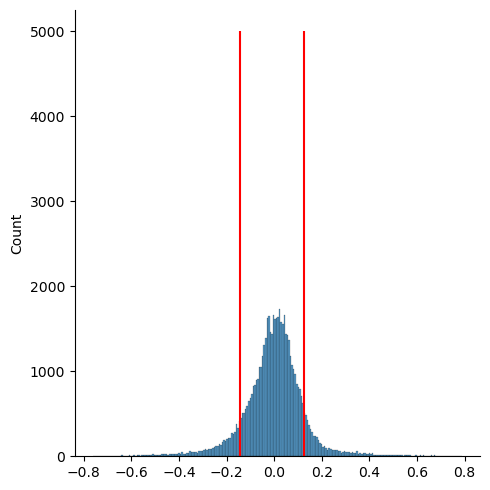

In [365]:
sns.displot(case_corrs.values.flatten())
plt.vlines([lower, upper], ymin=0, ymax=5000, colors=['red', 'red'], )

In [366]:
case_metrics['basal_layer_correlation'] = case_corrs.mean().loc[case_metrics.index.to_list()]
sample_metrics['basal_layer_correlation'] = sample_corrs.mean().loc[sample_metrics.index.to_list()]

In [367]:
case_metrics['positive_passed_threshold'] = (case_corrs > upper).sum().loc[case_metrics.index.to_list()]
sample_metrics['positive_passed_threshold'] = (sample_corrs > upper).sum().loc[sample_metrics.index.to_list()]

In [368]:
case_metrics['negative_passed_threshold'] = (case_corrs < lower).sum().loc[case_metrics.index.to_list()]
sample_metrics['negative_passed_threshold'] = (sample_corrs < lower).sum().loc[sample_metrics.index.to_list()]

In [369]:
case_metrics['positive_passed_threshold_fraction'] = ((case_corrs > upper).sum() / (~pd.isnull(case_corrs)).sum()).loc[case_metrics.index.to_list()]
sample_metrics['positive_passed_threshold_fraction'] = ((sample_corrs > upper).sum() / (~pd.isnull(sample_corrs)).sum()).loc[sample_metrics.index.to_list()]

In [370]:
case_metrics['negative_passed_threshold_fraction'] = ((case_corrs < lower).sum() / (~pd.isnull(case_corrs)).sum()).loc[case_metrics.index.to_list()]
sample_metrics['negative_passed_threshold_fraction'] = ((sample_corrs < lower).sum() / (~pd.isnull(sample_corrs)).sum()).loc[sample_metrics.index.to_list()]

In [371]:
case_metrics['total_count'] = (~pd.isnull(case_corrs)).sum().loc[case_metrics.index.to_list()]
sample_metrics['total_count'] = (~pd.isnull(sample_corrs)).sum().loc[sample_metrics.index.to_list()]

In [372]:
case_metrics.to_csv(output_dir / f'metrics_{mask_type}s_caselevel_{disease}.txt', sep='\t')
sample_metrics.to_csv(output_dir / f'metrics_{mask_type}s_samplelevel_{disease}.txt', sep='\t')

## Cosmx processing

In [6]:
inputs_dir = Path('../data/spatial/inputs/cosmx')
output_dir = Path('../data/spatial/regions/cosmx')
output_dir.mkdir(parents=True, exist_ok=True)

In [7]:
transcript_fps = sorted([inputs_dir / p for p in os.listdir(inputs_dir) if '_transcripts.parquet' in p])
adata_fps = sorted([inputs_dir / p for p in os.listdir(inputs_dir) if '_counts.h5ad' in p])

In [8]:
transcript_fps

[PosixPath('../data/spatial/inputs/cosmx/HT206B1-H2L1U23_1_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U14_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U22_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U47_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U56_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H1Fp1_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H3FP1U57_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H3FP1U60_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H4Fp1_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT913Z1-S1H1Fp1_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT935Z1-S1H1FP1U2_transcripts.parquet'),
 PosixPath('../data/spatial/inputs/cosmx/HT938Z1-S1H1FP1U1_transcripts.parquet'),
 PosixPath('

In [9]:
adata_fps

[PosixPath('../data/spatial/inputs/cosmx/HT206B1-H2L1U23_1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U14_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U22_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U47_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT704B1-S1H3Fp1_U56_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H1Fp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H3FP1U57_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H3FP1U60_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT891Z1-S2H4Fp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT913Z1-S1H1Fp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT935Z1-S1H1FP1U2_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT938Z1-S1H1FP1U1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/cosmx/HT997Z1-S1H1FP1U1_counts.h5ad'),
 PosixPath('../data/spatial/inputs

HT938Z1-S1H1FP1U1
(1041, 706, 1)


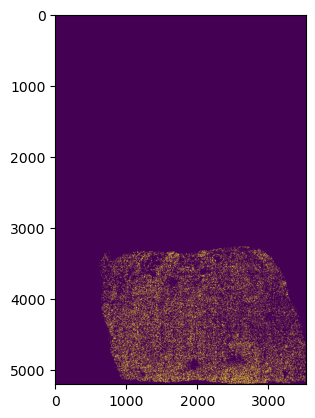

HT997Z1-S1H1FP1U1
(537, 342, 1)


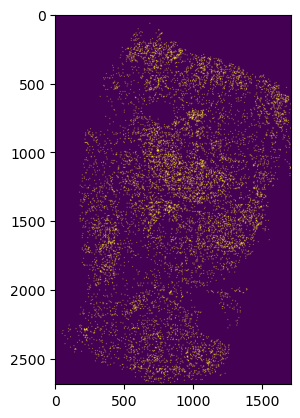

SP005Z1-Fp1A25-Ux
(714, 227, 1)


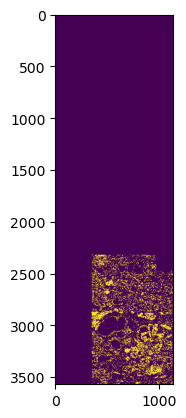

SP012Z1-Fp1A15-Ux
(218, 156, 1)


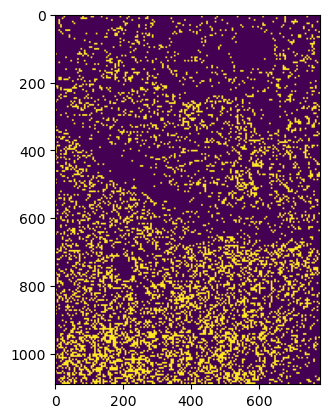

SP012Z1-Fp1A2-Ux
(651, 369, 1)


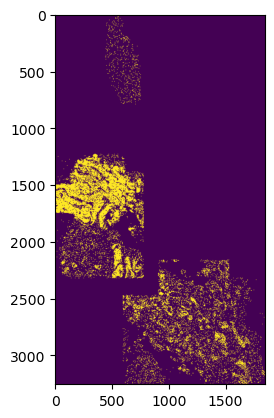

In [10]:
transcripts = None
import torch
import torchvision.transforms.functional as TF
for transcript_fp, adata_fp in list(zip(transcript_fps, adata_fps))[11:]:
    sid = str(transcript_fp).split('/')[-1].replace('_transcripts.parquet', '')
    print(sid)
    adata = sc.read_h5ad(adata_fp)
    adata = process_adata(adata)
    
    transcripts = pd.read_parquet(transcript_fp)
    keep = ['EPCAM']
    transcripts = transcripts[[x in keep for x in transcripts['feature_name']]]
        
    img, genes = tile_cosmx(adata, tile_size=50, transcripts=transcripts)
    img = rearrange(img, 'h w c -> c h w')
    img = TF.resize(torch.tensor(img), size=(img.shape[-2] * 5, img.shape[-1] * 5), interpolation=TF.InterpolationMode.NEAREST_EXACT, antialias=False)
    img = img.numpy()[0]
    img = rearrange(img, 'h w -> h w 1')
    plt.imshow(img > 0)
    plt.show()
    
    np.save(output_dir / f'{sid}_epcam_tiled.npy', img)
    adata.write_h5ad(output_dir / f'{sid}.h5ad')

In [11]:
fps = [output_dir / p for p in os.listdir(output_dir) if 'epcam_tiled.npy' in p]
fps

[PosixPath('../data/spatial/regions/cosmx/SP012Z1-Fp1A2-Ux_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT913Z1-S1H1Fp1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT891Z1-S2H4Fp1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT938Z1-S1H1FP1U1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/SP005Z1-Fp1A25-Ux_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT997Z1-S1H1FP1U1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT704B1-S1H3Fp1_U56_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT704B1-S1H3Fp1_U14_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT704B1-S1H3Fp1_U47_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT891Z1-S2H3FP1U60_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT891Z1-S2H3FP1U57_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/HT206B1-H2L1U23_1_epcam_tiled.npy'),
 PosixPath('../data/spatial/regions/cosmx/SP012Z1

In [12]:
from skimage.morphology import label, remove_small_objects
for fp in fps:
    sid = str(fp).split('/')[-1].replace('_epcam_tiled.npy', '')
    print(sid)
    x = np.load(fp)[..., 0]
    
    norm = x / x.std()
    mask = norm > 1
    labeled, ring_labels, tme_labels = process_and_save_mask(mask)
    
    np.save(output_dir / f'{sid}_epi_region_labeled.npy', labeled)
    np.save(output_dir / f'{sid}_epi_ring_labeled.npy', ring_labels)
    np.save(output_dir / f'{sid}_epi_tme_labeled.npy', tme_labels)

SP012Z1-Fp1A2-Ux
HT913Z1-S1H1Fp1
HT891Z1-S2H4Fp1
HT938Z1-S1H1FP1U1
SP005Z1-Fp1A25-Ux
HT997Z1-S1H1FP1U1
HT704B1-S1H3Fp1_U56
HT704B1-S1H3Fp1_U14
HT704B1-S1H3Fp1_U47
HT891Z1-S2H3FP1U60
HT891Z1-S2H3FP1U57
HT206B1-H2L1U23_1
SP012Z1-Fp1A15-Ux
HT891Z1-S2H1Fp1
HT935Z1-S1H1FP1U2
HT704B1-S1H3Fp1_U22


In [13]:
for transcripts_fp in transcript_fps:
    sid = str(transcripts_fp).split('/')[-1].replace('_transcripts.parquet', '')
    print(sid)

    region_fp = output_dir / f'{sid}_epi_region_labeled.npy'
    
    transcripts = pd.read_parquet(transcripts_fp)
    transcripts = transcripts[['feature_name', 'x_location', 'y_location']]
    transcripts.columns = ['gene', 'x', 'y']
    transcripts['x'] /= 10
    transcripts['y'] /= 10
    
    transcripts = transcripts[transcripts['y'] >= 0]
    
    mapping = {
        'region': output_dir / f'{sid}_epi_region_labeled.npy',
        'boundary': output_dir / f'{sid}_epi_ring_labeled.npy',
        'tme': output_dir / f'{sid}_epi_tme_labeled.npy',
    }
    
    for k, fp in mapping.items():
        labeled = np.load(fp)
        df = count_genes_in_regions(labeled, transcripts, per_gene=True)
        df.to_csv(output_dir / f'{sid}_{k}_counts.txt', sep='\t')

HT206B1-H2L1U23_1
HT704B1-S1H3Fp1_U14
HT704B1-S1H3Fp1_U22
HT704B1-S1H3Fp1_U47
HT704B1-S1H3Fp1_U56
HT891Z1-S2H1Fp1
HT891Z1-S2H3FP1U57
HT891Z1-S2H3FP1U60
HT891Z1-S2H4Fp1
HT913Z1-S1H1Fp1
HT935Z1-S1H1FP1U2
HT938Z1-S1H1FP1U1
HT997Z1-S1H1FP1U1
SP005Z1-Fp1A25-Ux
SP012Z1-Fp1A15-Ux
SP012Z1-Fp1A2-Ux


In [14]:
fps = [output_dir / p for p in os.listdir(output_dir) if 'region_counts.txt' in p]
fps

[PosixPath('../data/spatial/regions/cosmx/HT891Z1-S2H3FP1U57_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT913Z1-S1H1Fp1_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT704B1-S1H3Fp1_U22_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT891Z1-S2H1Fp1_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/SP012Z1-Fp1A15-Ux_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT206B1-H2L1U23_1_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/SP012Z1-Fp1A2-Ux_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/SP005Z1-Fp1A25-Ux_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT891Z1-S2H4Fp1_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT704B1-S1H3Fp1_U56_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT938Z1-S1H1FP1U1_region_counts.txt'),
 PosixPath('../data/spatial/regions/cosmx/HT704B1-S1H3Fp1_U14_region_counts.txt'),
 PosixPath('../data/spatial/

In [15]:
combined = {
    'region': None,
    'boundary': None,
    'tme': None
}

for fp in fps:
    sid = str(fp).split('/')[-1].replace('_region_counts.txt', '')
    print(sid)
    
    mapping = {
        'region': output_dir / f'{sid}_region_counts.txt',
        'boundary': output_dir / f'{sid}_boundary_counts.txt',
        'tme': output_dir / f'{sid}_tme_counts.txt',
    }
    
    for k, fp in mapping.items():
        df = pd.read_csv(fp, sep='\t')
        df = df.set_index('region_id')
        df.index = [f'{sid}_{x}' for x in df.index.to_list()]
        
        if combined[k] is None:
            combined[k] = df
        else:
            combined[k] = pd.concat((combined[k], df))
        print(combined[k].shape)

HT891Z1-S2H3FP1U57
(8699, 6519)
(8700, 6519)
(8700, 6518)
HT913Z1-S1H1Fp1
(22396, 6552)
(22488, 6552)
(22537, 6551)
HT704B1-S1H3Fp1_U22
(27502, 6552)
(27703, 6552)
(27785, 6551)
HT891Z1-S2H1Fp1
(33845, 6552)
(34060, 6552)
(34144, 6551)
SP012Z1-Fp1A15-Ux
(36632, 6552)
(36847, 6552)
(36931, 6551)
HT206B1-H2L1U23_1
(39263, 6552)
(39502, 6552)
(39589, 6551)
SP012Z1-Fp1A2-Ux
(43922, 6552)
(44179, 6552)
(44266, 6551)
SP005Z1-Fp1A25-Ux
(46581, 6552)
(46839, 6552)
(46926, 6551)
HT891Z1-S2H4Fp1
(53977, 6552)
(54243, 6552)
(54329, 6551)
HT704B1-S1H3Fp1_U56
(57460, 6552)
(57802, 6552)
(57910, 6551)
HT938Z1-S1H1FP1U1
(76651, 6552)
(77004, 6552)
(77112, 6551)
HT704B1-S1H3Fp1_U14
(83764, 6552)
(84195, 6552)
(84298, 6551)
HT997Z1-S1H1FP1U1
(90401, 6552)
(90833, 6552)
(90937, 6551)
HT891Z1-S2H3FP1U60
(98217, 6552)
(98653, 6552)
(98755, 6551)
HT704B1-S1H3Fp1_U47
(104602, 6552)
(105088, 6552)
(105183, 6551)
HT935Z1-S1H1FP1U2
(115912, 6552)
(116408, 6552)
(116509, 6551)


In [16]:
for k, v in combined.items():
    v.index.name = 'region_id'
    v.to_parquet(output_dir / f'combined_counts_{k}.parquet')

In [17]:
for fp in fps:
    sid = str(fp).split('/')[-1].replace('_region_counts.txt', '')
    print(sid)

HT891Z1-S2H3FP1U57
HT913Z1-S1H1Fp1
HT704B1-S1H3Fp1_U22
HT891Z1-S2H1Fp1
SP012Z1-Fp1A15-Ux
HT206B1-H2L1U23_1
SP012Z1-Fp1A2-Ux
SP005Z1-Fp1A25-Ux
HT891Z1-S2H4Fp1
HT704B1-S1H3Fp1_U56
HT938Z1-S1H1FP1U1
HT704B1-S1H3Fp1_U14
HT997Z1-S1H1FP1U1
HT891Z1-S2H3FP1U60
HT704B1-S1H3Fp1_U47
HT935Z1-S1H1FP1U2


In [18]:
basal = pd.read_parquet(output_dir / f'combined_counts_boundary.parquet',
                        columns=['KRT5', 'KRT14', 'KRT15', 'LAMB3', 'ACTA2'])

values = np.full((basal.shape[0],), np.nan, dtype=basal.values.dtype)
for c in basal.columns:
    mask = pd.isnull(values)
    values[mask] = basal[c][mask]



case_meta = pd.read_csv('/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/data/spatial/metadata/2d_data_tracking_metadata.csv')
to_tnbc = {x:y for x, y in case_meta[['sid', 'is_tnbc']].values}

basal['sid'] = ['_'.join(x.split('_')[:-1]) for x in basal.index.to_list()]
basal['is_tnbc'] = [to_tnbc[sid] for sid in basal['sid']]

values[basal['is_tnbc']] = basal[basal['is_tnbc']]['ACTA2']

basal['basal'] = values

basal

,KRT5,KRT14,KRT15,LAMB3,ACTA2,sid,is_tnbc,basal
region_id,,,,,,,,
HT891Z1-S2H3FP1U57_1,0,0,0,0.0,0,HT891Z1-S2H3FP1U57,False,0.0
HT891Z1-S2H3FP1U57_2,0,0,0,0.0,0,HT891Z1-S2H3FP1U57,False,0.0
HT891Z1-S2H3FP1U57_3,0,0,0,0.0,0,HT891Z1-S2H3FP1U57,False,0.0
HT891Z1-S2H3FP1U57_4,0,1,0,0.0,2,HT891Z1-S2H3FP1U57,False,0.0
HT891Z1-S2H3FP1U57_5,1,0,0,0.0,1,HT891Z1-S2H3FP1U57,False,1.0
...,...,...,...,...,...,...,...,...
HT935Z1-S1H1FP1U2_11377,0,0,0,0.0,0,HT935Z1-S1H1FP1U2,False,0.0
HT935Z1-S1H1FP1U2_11380,0,1,1,0.0,0,HT935Z1-S1H1FP1U2,False,0.0
HT935Z1-S1H1FP1U2_11381,0,0,0,0.0,0,HT935Z1-S1H1FP1U2,False,0.0


In [19]:
assert np.count_nonzero(pd.isnull(basal['basal'])) == 0

In [20]:
df = pd.read_parquet(output_dir / f'combined_counts_region.parquet')
df.insert(0, 'sid', ['_'.join(x.split('_')[:-1]) for x in df.index.to_list()])
df['basal_target'] = basal['basal']
results = correlate_to_target_per_sample(df, target_gene='basal_target')
results.index.name = 'sid'
results.to_csv(output_dir / 'correlations_regions.txt', sep='\t')
results

,A1BG,A2M,AAAS,AAK1,AAMP,AARS1,AASS,AATK,ABAT,ABCA1,...,RPL21,RPL22,RPL32,RPL34,RPL37,RPS4Y1,SAA1/2,TPSAB1/B2,TPT1,UBA52
sid,,,,,,,,,,,,,,,,,,,,,
HT891Z1-S2H3FP1U57,0.058104,0.045450,0.053712,0.027784,0.076435,0.065798,0.065550,0.072527,0.051865,0.041871,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT913Z1-S1H1Fp1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.124328,NaN,NaN,...,0.073040,0.121946,0.092914,0.095589,0.104469,0.130318,0.137469,0.119461,0.108268,0.107463
HT704B1-S1H3Fp1_U22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.204241,NaN,NaN,...,0.178869,0.201732,0.201238,0.236036,0.238239,0.146154,0.255398,0.175756,0.207245,0.190594
HT891Z1-S2H1Fp1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130498,NaN,NaN,...,0.091138,0.111266,0.093376,0.091030,0.089849,0.116261,0.111721,0.111766,0.091598,0.110650
SP012Z1-Fp1A15-Ux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.146554,NaN,NaN,...,0.033970,0.084711,0.031840,0.069131,0.051128,0.062014,0.117197,0.117125,0.104526,0.096763
HT206B1-H2L1U23_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.168509,NaN,NaN,...,0.199173,0.213902,0.239639,0.216626,0.223581,0.150207,0.236522,0.233608,0.245204,0.233592
SP012Z1-Fp1A2-Ux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.183553,NaN,NaN,...,0.127673,0.138493,0.135968,0.148265,0.118494,0.187641,0.183007,0.139202,0.113207,0.164775
SP005Z1-Fp1A25-Ux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.183186,NaN,NaN,...,0.153803,0.131192,0.135735,0.177138,0.111904,0.159659,0.298085,0.179035,0.113119,0.118413
HT891Z1-S2H4Fp1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.128504,NaN,NaN,...,0.124563,0.118177,0.118124,0.098686,0.124468,0.118908,0.122250,0.114721,0.083924,0.125736


In [21]:
df = pd.read_parquet(output_dir / f'combined_counts_tme.parquet')
df.insert(0, 'sid', ['_'.join(x.split('_')[:-1]) for x in df.index.to_list()])
df['basal_target'] = basal['basal']
results = correlate_to_target_per_sample(df, target_gene='basal_target')
results.index.name = 'sid'
results.to_csv(output_dir / 'correlations_tme.txt', sep='\t')
results

,A1BG,A2M,AAAS,AAK1,AAMP,AARS1,AASS,AATK,ABAT,ABCA1,...,RPL21,RPL22,RPL32,RPL34,RPL37,RPS4Y1,SAA1/2,TPSAB1/B2,TPT1,UBA52
sid,,,,,,,,,,,,,,,,,,,,,
HT891Z1-S2H3FP1U57,0.009348,0.017273,0.046409,0.022018,0.037353,0.024236,0.033554,0.036546,0.029773,0.024776,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT913Z1-S1H1Fp1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.071351,NaN,NaN,...,0.034965,0.055469,0.058048,0.055058,0.058614,0.064436,0.075441,0.068046,0.058743,0.059504
HT704B1-S1H3Fp1_U22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.150590,NaN,NaN,...,0.182441,0.209330,0.211664,0.226189,0.258215,0.122841,0.247916,0.121720,0.209677,0.173143
HT891Z1-S2H1Fp1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.071339,NaN,NaN,...,0.089105,0.066617,0.048899,0.085779,0.057992,0.060544,0.080507,0.053739,0.072832,0.073316
SP012Z1-Fp1A15-Ux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.110597,NaN,NaN,...,0.033780,0.028933,-0.009754,0.065528,0.009906,0.040520,0.042138,0.108633,0.072349,0.032224
HT206B1-H2L1U23_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197367,NaN,NaN,...,0.172219,0.198908,0.211637,0.222357,0.189532,0.114203,0.204026,0.177697,0.195525,0.183426
SP012Z1-Fp1A2-Ux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083549,NaN,NaN,...,0.124136,0.074886,0.098561,0.068183,0.085914,0.068194,0.086327,0.086026,0.061869,0.105241
SP005Z1-Fp1A25-Ux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.135404,NaN,NaN,...,0.173090,0.118298,0.103538,0.132814,0.111300,0.080833,0.302082,0.101372,0.108126,0.109193
HT891Z1-S2H4Fp1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.072645,NaN,NaN,...,0.085155,0.084122,0.069185,0.062656,0.069693,0.059157,0.069939,0.079952,0.073661,0.056187


## cosmx analysis

In [86]:
# disease = 'prostate'
disease = 'breast'

# mask_type = 'region'
mask_type = 'tme'

sid_to_tissue = {x:y for x, y in case_meta[['sid', 'tissue']].values}

In [87]:
ext = 's' if mask_type == 'region' else ''
sample_corrs = pd.read_csv(output_dir / f'correlations_{mask_type}{ext}.txt', sep='\t', index_col=0)
sample_corrs = sample_corrs[[sid_to_tissue[k] == disease if disease != 'all' else True
                           for k in sample_corrs.index.to_list()]]

case_corrs = sample_corrs.copy()
case_corrs.insert(0,'case', [x.split('-')[0].split('_')[0].replace('U1', '') for x in case_corrs.index.to_list()])
case_corrs = case_corrs.groupby('case').mean()
case_corrs.to_csv(output_dir / f'correlations_{mask_type}s_caselevel_{disease}.txt', sep='\t')
sample_corrs.to_csv(output_dir / f'correlations_{mask_type}s_samplelevel_{disease}.txt', sep='\t')

case_corrs

,A1BG,A2M,AAAS,AAK1,AAMP,AARS1,AASS,AATK,ABAT,ABCA1,...,RPL21,RPL22,RPL32,RPL34,RPL37,RPS4Y1,SAA1/2,TPSAB1/B2,TPT1,UBA52
case,,,,,,,,,,,,,,,,,,,,,
HT206B1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197367,NaN,NaN,...,0.172219,0.198908,0.211637,0.222357,0.189532,0.114203,0.204026,0.177697,0.195525,0.183426
HT704B1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.126684,NaN,NaN,...,0.161519,0.180486,0.179502,0.207845,0.228276,0.119562,0.220984,0.092658,0.171299,0.146705


In [88]:
sample_corrs

,A1BG,A2M,AAAS,AAK1,AAMP,AARS1,AASS,AATK,ABAT,ABCA1,...,RPL21,RPL22,RPL32,RPL34,RPL37,RPS4Y1,SAA1/2,TPSAB1/B2,TPT1,UBA52
sid,,,,,,,,,,,,,,,,,,,,,
HT704B1-S1H3Fp1_U22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.150590,NaN,NaN,...,0.182441,0.209330,0.211664,0.226189,0.258215,0.122841,0.247916,0.121720,0.209677,0.173143
HT206B1-H2L1U23_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197367,NaN,NaN,...,0.172219,0.198908,0.211637,0.222357,0.189532,0.114203,0.204026,0.177697,0.195525,0.183426
HT704B1-S1H3Fp1_U56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.125589,NaN,NaN,...,0.199109,0.194891,0.213536,0.229127,0.280741,0.139784,0.272364,0.070408,0.197860,0.154407
HT704B1-S1H3Fp1_U14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.132097,NaN,NaN,...,0.167877,0.178185,0.185898,0.216422,0.231400,0.129857,0.207028,0.113490,0.157853,0.150782
HT704B1-S1H3Fp1_U47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098460,NaN,NaN,...,0.096649,0.139538,0.106911,0.159643,0.142746,0.085766,0.156627,0.065017,0.119804,0.108489


In [89]:
arr = case_corrs.values.flatten()
arr = arr[~pd.isnull(arr)]
lower, upper = np.percentile(arr, [10, 90])
lower, upper

(np.float64(0.05730185961266837), np.float64(0.20348769497722266))

In [90]:
sample_metrics = pd.DataFrame(index=sample_corrs.columns)
case_metrics = pd.DataFrame(index=case_corrs.columns)

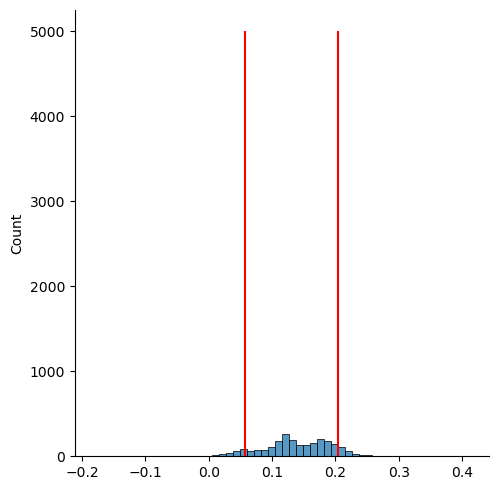

In [91]:
sns.displot(case_corrs.values.flatten())
plt.vlines([lower, upper], ymin=0, ymax=5000, colors=['red', 'red'], )

In [92]:
case_metrics['basal_layer_correlation'] = case_corrs.mean().loc[case_metrics.index.to_list()]
sample_metrics['basal_layer_correlation'] = sample_corrs.mean().loc[sample_metrics.index.to_list()]

In [93]:
case_metrics['positive_passed_threshold'] = (case_corrs > upper).sum().loc[case_metrics.index.to_list()]
sample_metrics['positive_passed_threshold'] = (sample_corrs > upper).sum().loc[sample_metrics.index.to_list()]

In [94]:
case_metrics['negative_passed_threshold'] = (case_corrs < lower).sum().loc[case_metrics.index.to_list()]
sample_metrics['negative_passed_threshold'] = (sample_corrs < lower).sum().loc[sample_metrics.index.to_list()]

In [95]:
case_metrics['positive_passed_threshold_fraction'] = ((case_corrs > upper).sum() / (~pd.isnull(case_corrs)).sum()).loc[case_metrics.index.to_list()]
sample_metrics['positive_passed_threshold_fraction'] = ((sample_corrs > upper).sum() / (~pd.isnull(sample_corrs)).sum()).loc[sample_metrics.index.to_list()]

In [96]:
case_metrics['negative_passed_threshold_fraction'] = ((case_corrs < lower).sum() / (~pd.isnull(case_corrs)).sum()).loc[case_metrics.index.to_list()]
sample_metrics['negative_passed_threshold_fraction'] = ((sample_corrs < lower).sum() / (~pd.isnull(sample_corrs)).sum()).loc[sample_metrics.index.to_list()]

In [97]:
case_metrics['total_count'] = (~pd.isnull(case_corrs)).sum().loc[case_metrics.index.to_list()]
sample_metrics['total_count'] = (~pd.isnull(sample_corrs)).sum().loc[sample_metrics.index.to_list()]

In [98]:
case_metrics.to_csv(output_dir / f'metrics_{mask_type}s_caselevel_{disease}.txt', sep='\t')
sample_metrics.to_csv(output_dir / f'metrics_{mask_type}s_samplelevel_{disease}.txt', sep='\t')

## Visium HD processing

In [244]:
inputs_dir = Path('../data/spatial/inputs/visiumhd')
output_dir = Path('../data/spatial/regions/visiumhd')
output_dir.mkdir(parents=True, exist_ok=True)

In [245]:
adata_fps = [inputs_dir / p for p in os.listdir(inputs_dir) if '_counts.h5ad' in p]

In [246]:
adata_fps

[PosixPath('../data/spatial/inputs/visiumhd/HT727B1-S1H4Fp1U1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT935Z1-S1H1Fp1U2_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT891Z1-S2H3Fp1U2_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT704B1-S1H3Fp1U51_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT935Z1-S1H1Fp1U1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT704B1-S1H3Fp1U2_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT891Z1-S2H3Fp1U33_counts.h5ad')]

In [247]:
predicted_cases = [
    'HT891Z1',
    'HT704B1'
]

In [248]:
fps = [fp for fp in adata_fps if str(fp).split('/')[-1].split('-')[0] not in predicted_cases]
fps

[PosixPath('../data/spatial/inputs/visiumhd/HT727B1-S1H4Fp1U1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT935Z1-S1H1Fp1U2_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visiumhd/HT935Z1-S1H1Fp1U1_counts.h5ad')]

HT727B1-S1H4Fp1U1


/miniconda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


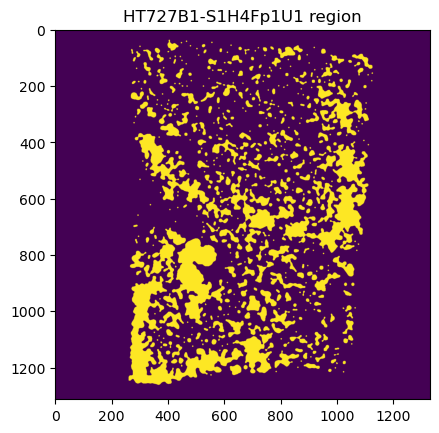

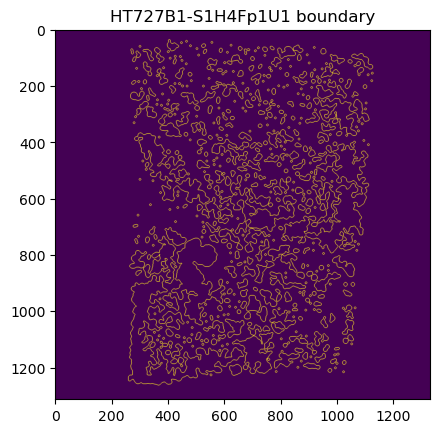

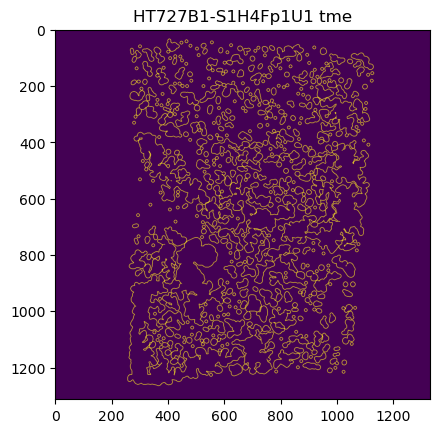

HT935Z1-S1H1Fp1U2


/miniconda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


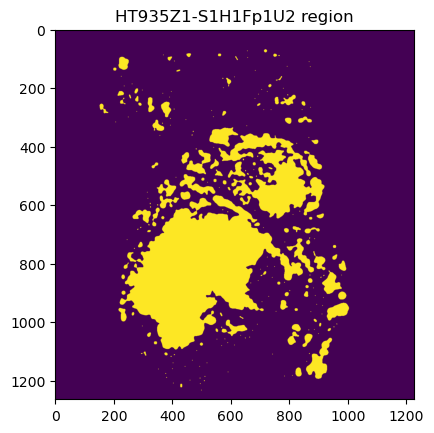

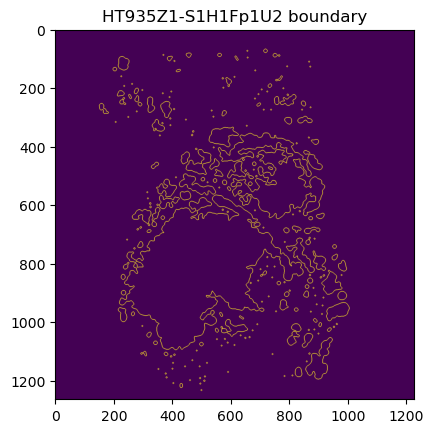

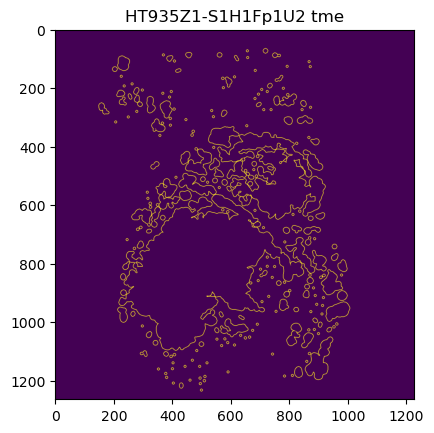

HT935Z1-S1H1Fp1U1


/miniconda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


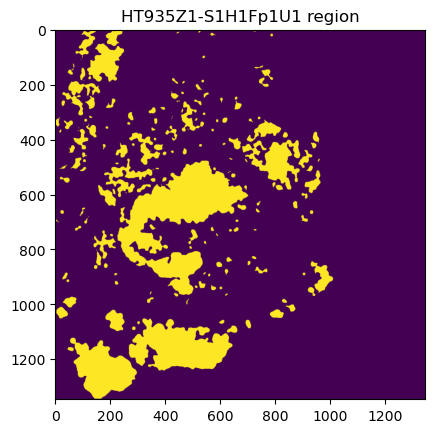

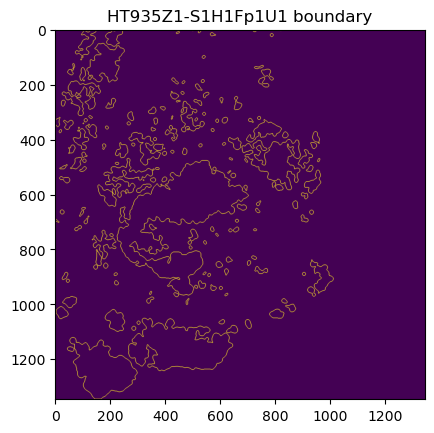

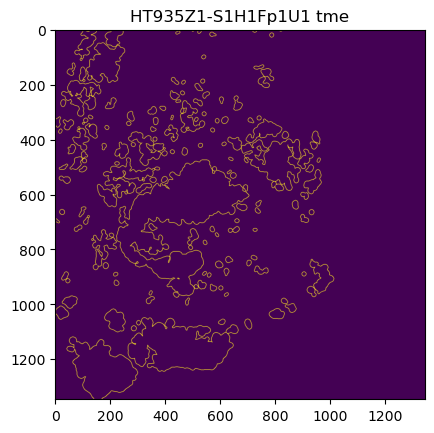

In [249]:

for adata_fp in fps:
    sid = str(adata_fp).split('/')[-1].replace('_counts.h5ad', '')
    print(sid)
    adata = sc.read_h5ad(adata_fp)
    adata.var_names_make_unique()
    keep = ['EPCAM']
    f = adata[:, keep]
    
    # gaussian blurred exp
    img = visiumhd_to_tiled(f, tile_size = 10, channels = keep)[0]
    img /= img.std()
    
    img_f = gaussian_filter(img, 5.)
    mask = img_f > .1
    
    labeled, ring_labels, tme_labels = process_and_save_mask(mask)
    
    plt.imshow(labeled > 0)
    plt.title(f'{sid} region')
    plt.show()
    
    plt.imshow(ring_labels > 0)
    plt.title(f'{sid} boundary')
    plt.show()
    
    plt.imshow(tme_labels > 0)
    plt.title(f'{sid} tme')
    plt.show()
    
    np.save(output_dir / f'{sid}_epi_region_labeled.npy', labeled)
    np.save(output_dir / f'{sid}_epi_ring_labeled.npy', ring_labels)
    np.save(output_dir / f'{sid}_epi_tme_labeled.npy', tme_labels)    

In [250]:
adata_mapping = {
    'HT704B1-S1H3Fp1U2': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/submission_v1/HT704B1/registered/HT704B1-U2_visiumhd.h5ad',
    'HT704B1-S1H3Fp1U51': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/submission_v1/HT704B1/registered/HT704B1-U51_visiumhd.h5ad',
    'HT891Z1-S2H3Fp1U2': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/submission_v1/HT891Z1/registered/HT891Z1-U2_visiumhd.h5ad',
    'HT891Z1-S2H3Fp1U33': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/submission_v1/HT891Z1/registered/HT891Z1-U33_visiumhd.h5ad',
}


predicted_mapping = {
    'HT891Z1-S2H3Fp1U2': '../data/spatial/inputs/visiumhd/HT891Z1-U2.ome.tif',
    'HT891Z1-S2H3Fp1U33': '../data/spatial/inputs/visiumhd/HT891Z1-U33.ome.tif',
    'HT704B1-S1H3Fp1U51': '../data/spatial/inputs/visiumhd/HT704B1-U51.ome.tif',
    'HT704B1-S1H3Fp1U2': '../data/spatial/inputs/visiumhd/HT704B1-U2.ome.tif'
}

target_idx_mapping = {
    'HT891Z1-S2H3Fp1U2': 1,
    'HT891Z1-S2H3Fp1U33': 1,
    'HT704B1-S1H3Fp1U51': 0,
    'HT704B1-S1H3Fp1U2': 0
}


In [251]:
# img = tifffile.imread('../data/spatial/inputs/visiumhd/HT704B1-U51.ome.tif')[0]
# img.shape

HT891Z1-S2H3Fp1U2


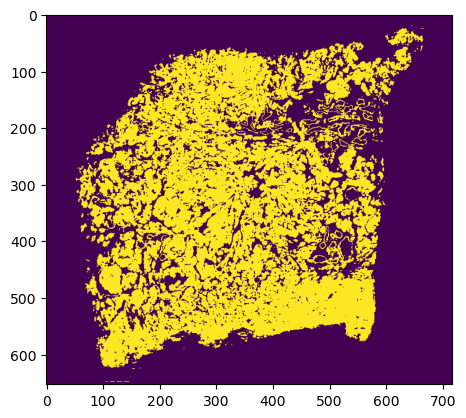

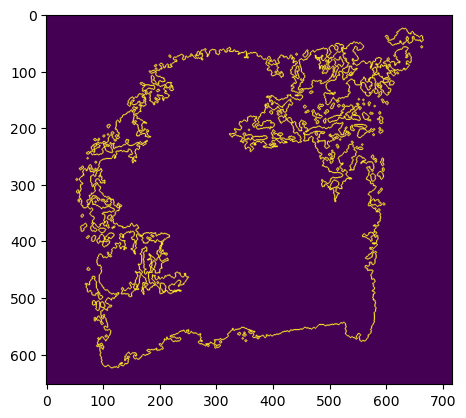

HT891Z1-S2H3Fp1U33


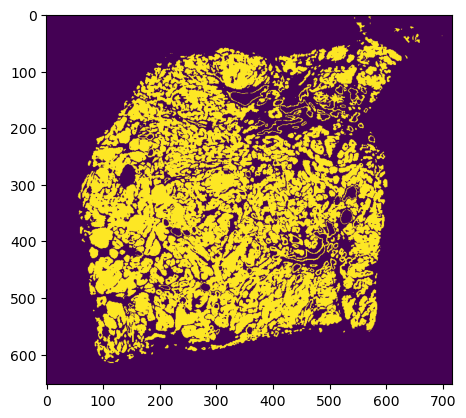

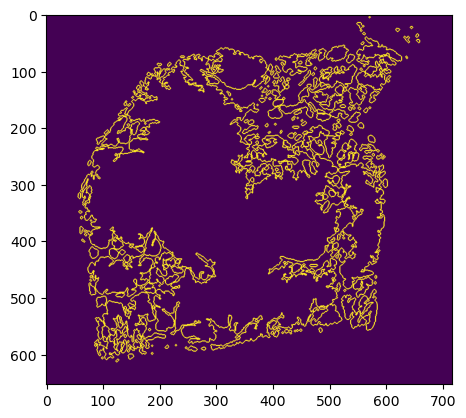

HT704B1-S1H3Fp1U51


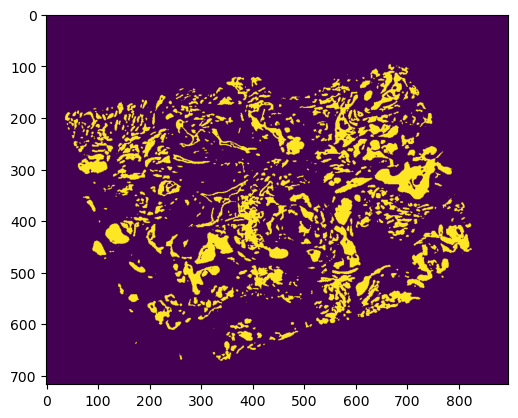

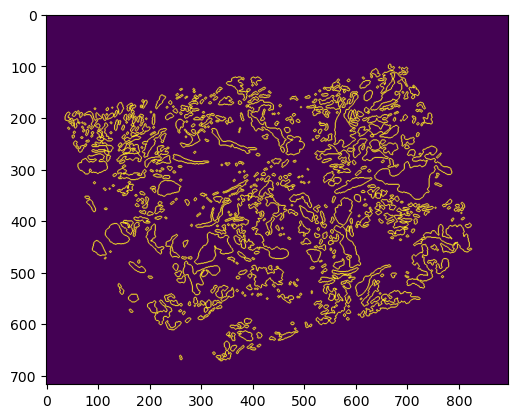

HT704B1-S1H3Fp1U2


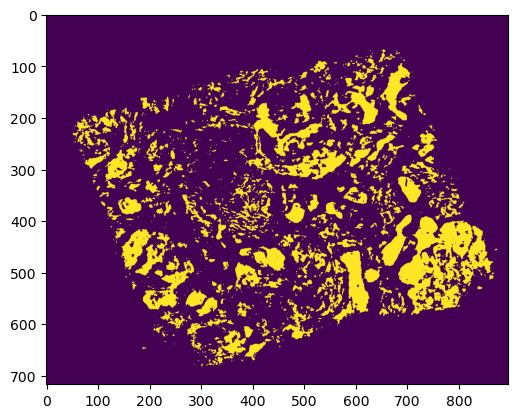

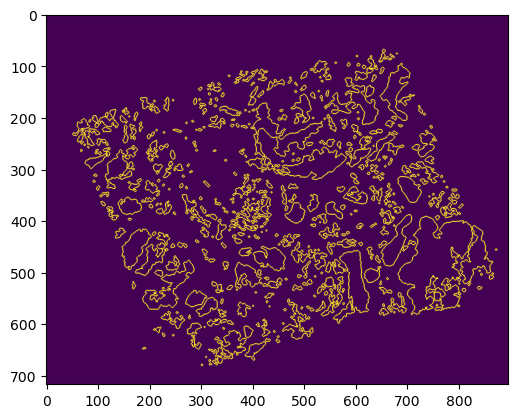

In [252]:
for sid, fp in predicted_mapping.items():
    print(sid)
    idx = target_idx_mapping[sid]
    img = tifffile.imread(fp)[idx]
    img = img.astype(np.float32)
    img /= img.std()

    mask = img > 1.
    mask = mask[::10, ::10] # downsample to 10 microns per pixel
    plt.imshow(mask)
    plt.show()

    labeled, ring_labels, tme_labels = process_and_save_mask(mask)
    plt.imshow(ring_labels > 0)
    plt.show()
    np.save(output_dir / f'{sid}_epi_region_labeled.npy', labeled)
    np.save(output_dir / f'{sid}_epi_ring_labeled.npy', ring_labels)
    np.save(output_dir / f'{sid}_epi_tme_labeled.npy', tme_labels)

In [253]:
# adata = sc.read_h5ad('/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/submission_v1/HT704B1/registered/HT704B1-U2_visiumhd.h5ad')
# adata

HT704B1-S1H3Fp1U2


/miniconda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(7367183, 18085)


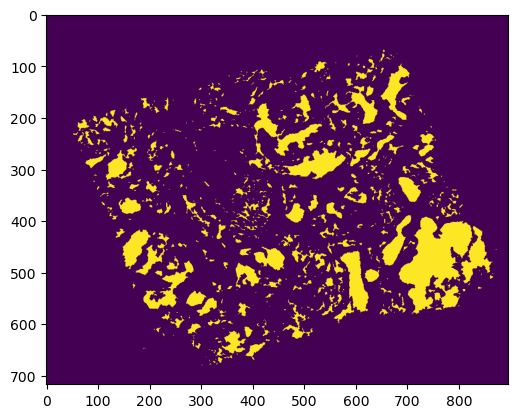

region (598, 18085)


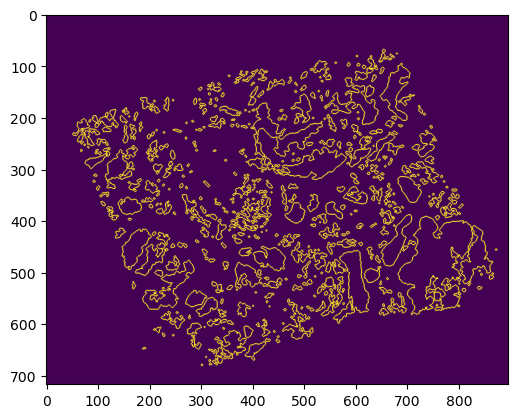

boundary (601, 18085)


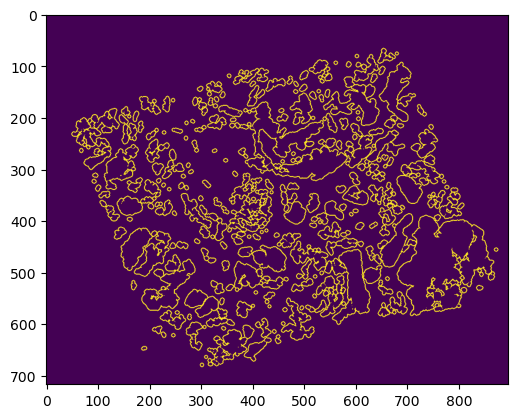

tme (605, 18085)
HT704B1-S1H3Fp1U51


/miniconda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(6937940, 18085)


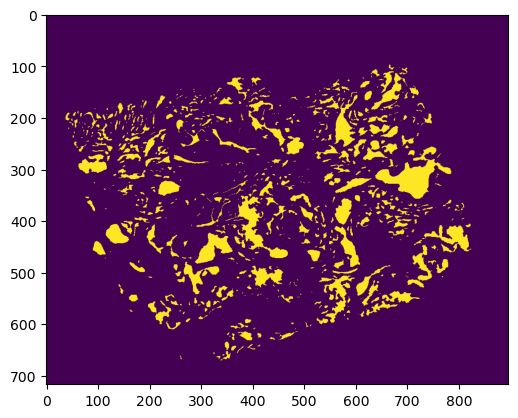

region (682, 18085)


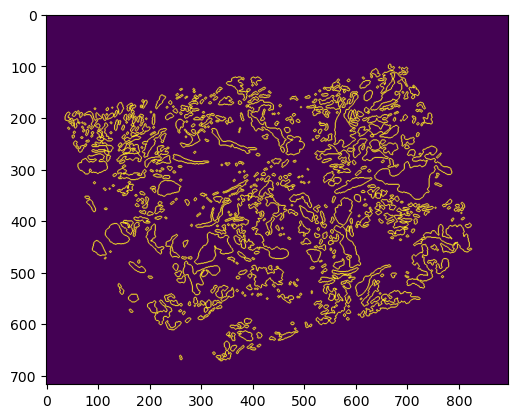

boundary (692, 18085)


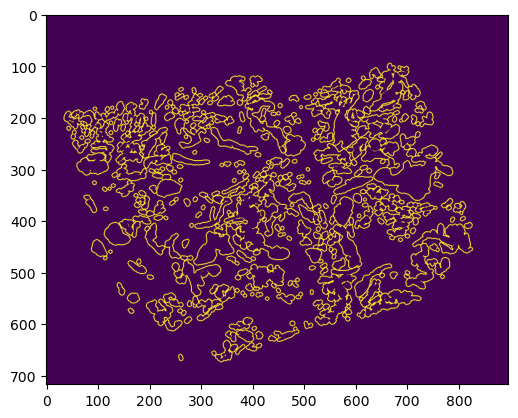

tme (695, 18085)
HT891Z1-S2H3Fp1U2


/miniconda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(6458371, 18085)


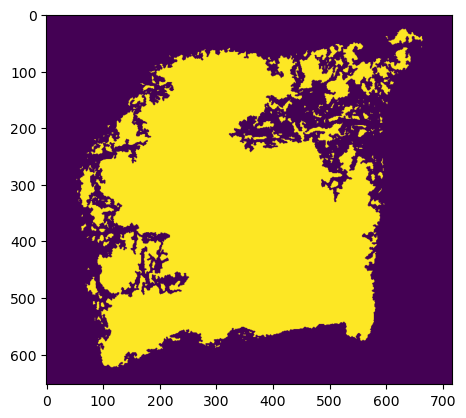

region (241, 18085)


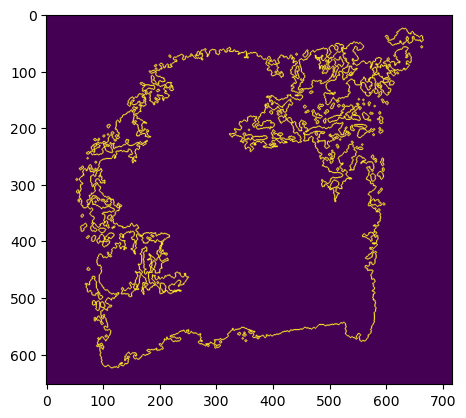

boundary (242, 18085)


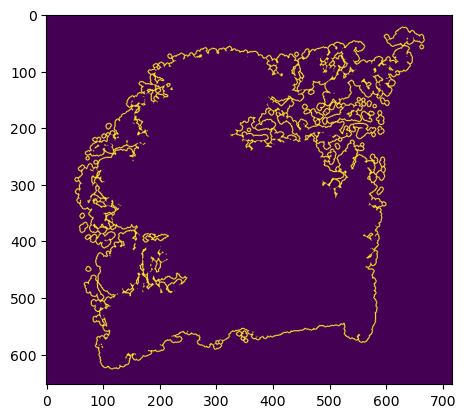

tme (242, 18085)
HT891Z1-S2H3Fp1U33


/miniconda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(5626166, 18085)


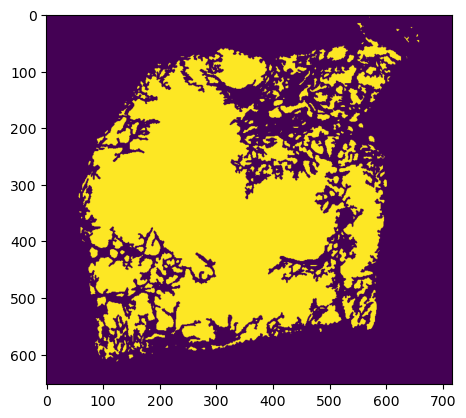

region (264, 18085)


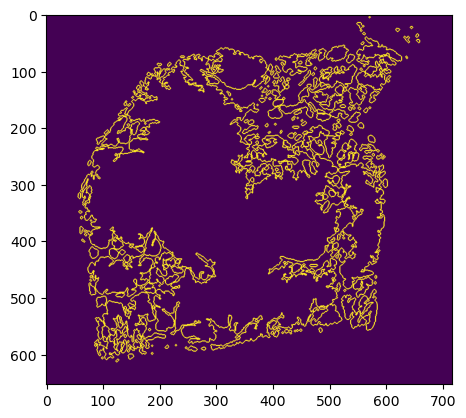

boundary (269, 18085)


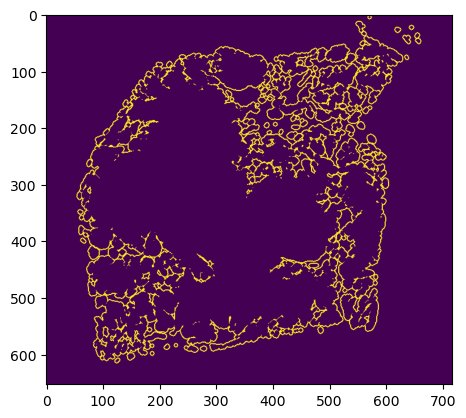

tme (271, 18085)


In [254]:
for sid, fp in adata_mapping.items():
    print(sid)
    adata = sc.read_h5ad(fp)
    print(adata.shape)
    adata.obs['x_location'] /= 10
    adata.obs['y_location'] /= 10

    mapping = {
        'region': output_dir / f'{sid}_epi_region_labeled.npy',
        'boundary': output_dir / f'{sid}_epi_ring_labeled.npy',
        'tme': output_dir / f'{sid}_epi_tme_labeled.npy',
    }
    
    for k, fp in mapping.items():
        labeled = np.load(fp)
        plt.imshow(labeled > 0)
        plt.show()
        df = aggregate_counts_by_region(adata, labeled, 1)
        print(k, df.shape)
        df.to_csv(output_dir / f'{sid}_{k}_counts.txt', sep='\t')


In [295]:
# def get_gene(labeled, gene, counts_df):
#     new = np.zeros_like(labeled)
#     for l, row in counts_df.iterrows():
#         new[labeled == l] = row[gene]
#     return new


# prefix = '../data/spatial/regions/xenium/HT704B1-S1H3Fp1U17'
# for rtype in ['region', 'boundary', 'tme']:
#     counts_df = pd.read_csv(f'{prefix}_{rtype}_counts.txt', sep='\t', index_col=0)
    
# #     ext = {'boundary': 'ring'}.get(rtype, rtype)
#     ext = 'region'
#     x = np.load(f'{prefix}_epi_{ext}_labeled.npy')
#     plt.imshow(get_gene(x, 'KRT5', counts_df))
#     plt.show()

In [296]:
fps = [output_dir / p for p in os.listdir(output_dir) if 'region_counts.txt' in p]
fps

[PosixPath('../data/spatial/regions/visiumhd/HT935Z1-S1H1Fp1U1_region_counts.txt'),
 PosixPath('../data/spatial/regions/visiumhd/HT891Z1-S2H3Fp1U2_region_counts.txt'),
 PosixPath('../data/spatial/regions/visiumhd/HT704B1-S1H3Fp1U2_region_counts.txt'),
 PosixPath('../data/spatial/regions/visiumhd/HT891Z1-S2H3Fp1U33_region_counts.txt'),
 PosixPath('../data/spatial/regions/visiumhd/HT727B1-S1H4Fp1U1_region_counts.txt'),
 PosixPath('../data/spatial/regions/visiumhd/HT935Z1-S1H1Fp1U2_region_counts.txt'),
 PosixPath('../data/spatial/regions/visiumhd/HT704B1-S1H3Fp1U51_region_counts.txt')]

In [298]:
combined = {
    'region': None,
    'boundary': None,
    'tme': None
}

for fp in fps:
    sid = str(fp).split('/')[-1].replace('_region_counts.txt', '')

    print(sid)
    
    mapping = {
        'region': output_dir / f'{sid}_region_counts.txt',
        'boundary': output_dir / f'{sid}_boundary_counts.txt',
        'tme': output_dir / f'{sid}_tme_counts.txt',
    }
    
    for k, fp in mapping.items():
        df = pd.read_csv(fp, sep='\t')
        df = df.set_index('region_label')
        df.index.name = 'region_id'
        df.index = [f'{sid}_{x}' for x in df.index.to_list()]
        
        if combined[k] is None:
            combined[k] = df
        else:
            combined[k] = pd.concat((combined[k], df))
        print(sid, k, df.shape)

HT935Z1-S1H1Fp1U1
HT935Z1-S1H1Fp1U1 region (128, 18085)
HT935Z1-S1H1Fp1U1 boundary (130, 18085)
HT935Z1-S1H1Fp1U1 tme (130, 18085)
HT891Z1-S2H3Fp1U2
HT891Z1-S2H3Fp1U2 region (241, 18085)
HT891Z1-S2H3Fp1U2 boundary (242, 18085)
HT891Z1-S2H3Fp1U2 tme (242, 18085)
HT704B1-S1H3Fp1U2
HT704B1-S1H3Fp1U2 region (598, 18085)
HT704B1-S1H3Fp1U2 boundary (601, 18085)
HT704B1-S1H3Fp1U2 tme (605, 18085)
HT891Z1-S2H3Fp1U33
HT891Z1-S2H3Fp1U33 region (264, 18085)
HT891Z1-S2H3Fp1U33 boundary (269, 18085)
HT891Z1-S2H3Fp1U33 tme (271, 18085)
HT727B1-S1H4Fp1U1
HT727B1-S1H4Fp1U1 region (428, 18085)
HT727B1-S1H4Fp1U1 boundary (428, 18085)
HT727B1-S1H4Fp1U1 tme (429, 18085)
HT935Z1-S1H1Fp1U2
HT935Z1-S1H1Fp1U2 region (216, 18085)
HT935Z1-S1H1Fp1U2 boundary (219, 18085)
HT935Z1-S1H1Fp1U2 tme (221, 18085)
HT704B1-S1H3Fp1U51
HT704B1-S1H3Fp1U51 region (682, 18085)
HT704B1-S1H3Fp1U51 boundary (692, 18085)
HT704B1-S1H3Fp1U51 tme (695, 18085)


In [299]:
set([x.split('_')[0] for x in combined['boundary'].index])

{'HT704B1-S1H3Fp1U2',
 'HT704B1-S1H3Fp1U51',
 'HT727B1-S1H4Fp1U1',
 'HT891Z1-S2H3Fp1U2',
 'HT891Z1-S2H3Fp1U33',
 'HT935Z1-S1H1Fp1U1',
 'HT935Z1-S1H1Fp1U2'}

In [300]:
for k, v in combined.items():
    v.index.name = 'region_id'
    v.to_parquet(output_dir / f'combined_counts_{k}.parquet')

In [301]:
set(case_meta[case_meta['platform']=='visiumhd']['sid'])

{'HT704B1-S1H3Fp1U2',
 'HT704B1-S1H3Fp1U51',
 'HT727B1-S1H4Fp1U1',
 'HT891Z1-S2H3Fp1U2',
 'HT891Z1-S2H3Fp1U33',
 'HT935Z1-S1H1Fp1U1',
 'HT935Z1-S1H1Fp1U2'}

In [302]:
basal = pd.read_parquet(output_dir / f'combined_counts_boundary.parquet',
                        columns=['KRT5', 'KRT14', 'KRT15', 'LAMB3', 'ACTA2'])
basal['sid'] = ['_'.join(x.split('_')[:-1]) for x in basal.index.to_list()]

In [303]:
basal

,KRT5,KRT14,KRT15,LAMB3,ACTA2,sid
region_id,,,,,,
HT935Z1-S1H1Fp1U1_26,0.0,0.0,0.0,0.0,3.0,HT935Z1-S1H1Fp1U1
HT935Z1-S1H1Fp1U1_27,0.0,0.0,0.0,0.0,8.0,HT935Z1-S1H1Fp1U1
HT935Z1-S1H1Fp1U1_28,0.0,0.0,0.0,0.0,2.0,HT935Z1-S1H1Fp1U1
HT935Z1-S1H1Fp1U1_29,0.0,0.0,0.0,0.0,7.0,HT935Z1-S1H1Fp1U1
HT935Z1-S1H1Fp1U1_31,0.0,0.0,0.0,0.0,4.0,HT935Z1-S1H1Fp1U1
...,...,...,...,...,...,...
HT704B1-S1H3Fp1U51_701,0.0,0.0,303.0,2.0,38.0,HT704B1-S1H3Fp1U51
HT704B1-S1H3Fp1U51_702,0.0,0.0,1.0,0.0,11.0,HT704B1-S1H3Fp1U51
HT704B1-S1H3Fp1U51_703,0.0,0.0,43.0,0.0,5.0,HT704B1-S1H3Fp1U51


In [304]:
basal = pd.read_parquet(output_dir / f'combined_counts_boundary.parquet',
                        columns=['KRT5', 'KRT14', 'KRT15', 'LAMB3', 'ACTA2'])

values = np.full((basal.shape[0],), np.nan, dtype=basal.values.dtype)
for c in basal.columns:
    mask = pd.isnull(values)
    values[mask] = basal[c][mask]
# values = basal.values.sum(1)



case_meta = pd.read_csv('/storage1/fs1/dinglab/Active/Projects/estorrs/3d-analysis/data/spatial/metadata/2d_data_tracking_metadata.csv')
to_tnbc = {x:y for x, y in case_meta[['sid', 'is_tnbc']].values}

basal['sid'] = ['_'.join(x.split('_')[:-1]) for x in basal.index.to_list()]
basal['is_tnbc'] = [to_tnbc[sid] for sid in basal['sid']]

values[basal['is_tnbc']] = basal[basal['is_tnbc']]['ACTA2']

basal['basal'] = values

basal

,KRT5,KRT14,KRT15,LAMB3,ACTA2,sid,is_tnbc,basal
region_id,,,,,,,,
HT935Z1-S1H1Fp1U1_26,0.0,0.0,0.0,0.0,3.0,HT935Z1-S1H1Fp1U1,False,0.0
HT935Z1-S1H1Fp1U1_27,0.0,0.0,0.0,0.0,8.0,HT935Z1-S1H1Fp1U1,False,0.0
HT935Z1-S1H1Fp1U1_28,0.0,0.0,0.0,0.0,2.0,HT935Z1-S1H1Fp1U1,False,0.0
HT935Z1-S1H1Fp1U1_29,0.0,0.0,0.0,0.0,7.0,HT935Z1-S1H1Fp1U1,False,0.0
HT935Z1-S1H1Fp1U1_31,0.0,0.0,0.0,0.0,4.0,HT935Z1-S1H1Fp1U1,False,0.0
...,...,...,...,...,...,...,...,...
HT704B1-S1H3Fp1U51_701,0.0,0.0,303.0,2.0,38.0,HT704B1-S1H3Fp1U51,False,0.0
HT704B1-S1H3Fp1U51_702,0.0,0.0,1.0,0.0,11.0,HT704B1-S1H3Fp1U51,False,0.0
HT704B1-S1H3Fp1U51_703,0.0,0.0,43.0,0.0,5.0,HT704B1-S1H3Fp1U51,False,0.0


In [305]:
set(basal['sid'])

{'HT704B1-S1H3Fp1U2',
 'HT704B1-S1H3Fp1U51',
 'HT727B1-S1H4Fp1U1',
 'HT891Z1-S2H3Fp1U2',
 'HT891Z1-S2H3Fp1U33',
 'HT935Z1-S1H1Fp1U1',
 'HT935Z1-S1H1Fp1U2'}

In [306]:
df = pd.read_parquet(output_dir / f'combined_counts_region.parquet')
df.insert(0, 'sid', ['_'.join(x.split('_')[:-1]) for x in df.index.to_list()])
df['basal_target'] = basal['basal']
results = correlate_to_target_per_sample(df, target_gene='basal_target')
results.index.name = 'sid'
results.to_csv(output_dir / 'correlations_regions.txt', sep='\t')
results

/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/cor

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
sid,,,,,,,,,,,,,,,,,,,,,
HT935Z1-S1H1Fp1U1,0.054850,0.094992,0.159265,0.089509,0.146228,0.038131,0.051272,-0.025287,-0.024582,0.198463,...,-0.048106,-0.132260,-0.029615,-0.175728,-0.019214,-0.033835,-0.098564,0.087047,0.021802,-0.108333
HT891Z1-S2H3Fp1U2,0.099561,-0.021334,0.056442,0.089045,-0.025795,-0.060334,-0.031830,0.179327,0.045123,0.030039,...,-0.533077,-0.513664,-0.455801,-0.374666,-0.431425,-0.425576,-0.454718,-0.301052,-0.169256,-0.503638
HT704B1-S1H3Fp1U2,-0.012116,-0.117529,-0.104471,-0.028525,0.025600,0.063775,-0.098679,0.035609,0.020965,-0.056376,...,-0.225333,-0.198505,-0.204099,-0.218097,-0.219476,-0.191139,-0.197771,-0.148565,-0.129625,-0.322581
HT891Z1-S2H3Fp1U33,0.142193,-0.067160,0.008162,0.016771,-0.034001,-0.036685,0.025559,0.212697,0.094422,0.021616,...,-0.420939,-0.461671,-0.356405,-0.327820,-0.228983,-0.397119,-0.355115,-0.213909,-0.174447,-0.398768
HT727B1-S1H4Fp1U1,0.096576,0.152678,0.185385,0.235758,0.058075,0.093136,0.152405,0.146968,0.091593,0.103641,...,-0.027297,-0.075948,-0.140977,-0.171968,-0.061619,-0.034726,-0.112478,0.076451,0.046460,-0.094519
HT935Z1-S1H1Fp1U2,0.174619,0.387396,0.237088,0.096668,0.188162,0.136615,0.176279,0.232591,0.339972,0.173485,...,0.243974,0.173616,0.188043,0.184234,0.189809,0.198624,0.192646,0.212043,0.286993,0.220920
HT704B1-S1H3Fp1U51,0.021488,-0.035429,-0.025846,0.066082,-0.001230,0.123473,-0.063175,0.081937,0.053976,-0.026569,...,-0.072565,-0.020174,-0.102511,-0.188094,-0.100380,-0.076859,-0.113455,-0.115907,-0.089657,-0.170358


In [307]:
df = pd.read_parquet(output_dir / f'combined_counts_tme.parquet')
df.insert(0, 'sid', ['_'.join(x.split('_')[:-1]) for x in df.index.to_list()])
df['basal_target'] = basal['basal']
results = correlate_to_target_per_sample(df, target_gene='basal_target')
results.index.name = 'sid'
results.to_csv(output_dir / 'correlations_tme.txt', sep='\t')
results

/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/miniconda/lib/python3.11/site-packages/pandas/cor

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
sid,,,,,,,,,,,,,,,,,,,,,
HT935Z1-S1H1Fp1U1,-0.000489,0.031889,0.093343,-0.034061,-0.023992,0.146420,0.043718,0.208440,NaN,0.140879,...,0.018302,-0.139056,-0.050986,-0.154747,0.048891,-0.100914,-0.177351,0.049847,-0.073573,-0.170412
HT891Z1-S2H3Fp1U2,0.292428,0.161462,0.045941,0.057220,0.143589,0.036706,0.152492,0.465423,-0.011206,0.252948,...,-0.582065,-0.601234,-0.582376,-0.541308,-0.613609,-0.561343,-0.622504,-0.505685,-0.284856,-0.621619
HT704B1-S1H3Fp1U2,0.027201,-0.069353,0.022980,0.079623,0.066543,0.275915,-0.050073,0.317223,0.002737,-0.029483,...,-0.243804,-0.222062,-0.331734,-0.370658,-0.299665,-0.163864,-0.285680,-0.195676,-0.156797,-0.359130
HT891Z1-S2H3Fp1U33,0.024944,0.083485,0.194050,0.215366,0.142415,-0.063705,0.119301,0.169772,0.122419,0.089590,...,-0.315138,-0.326088,-0.314564,-0.283075,-0.235124,-0.257643,-0.317457,-0.277768,-0.113539,-0.301649
HT727B1-S1H4Fp1U1,0.167068,0.197481,0.139105,0.261526,0.146141,0.156814,0.070129,0.126267,0.083334,0.166819,...,-0.061342,-0.083823,-0.184442,-0.204709,-0.027005,-0.019972,-0.108007,-0.021380,0.011965,-0.180583
HT935Z1-S1H1Fp1U2,0.129203,0.131720,0.272537,0.212491,0.117478,0.104058,0.094399,0.126775,-0.038315,0.139236,...,0.112786,0.130061,0.117324,0.029693,0.094704,0.066800,0.098104,0.111463,0.171130,0.045821
HT704B1-S1H3Fp1U51,0.045814,0.043821,0.087994,0.155696,0.112681,0.255136,-0.077109,0.245193,0.136521,0.042325,...,-0.104829,-0.071246,-0.165045,-0.187140,-0.205633,-0.082035,-0.122033,-0.150411,-0.141325,-0.240811


## visiumhd analysis

In [188]:
output_dir

PosixPath('../data/spatial/regions/visiumhd')

In [225]:
disease = 'prostate'
# disease = 'breast'

# mask_type = 'region'
mask_type = 'tme'

sid_to_tissue = {x:y for x, y in case_meta[['sid', 'tissue']].values}

In [226]:
ext = 's' if mask_type == 'region' else ''
sample_corrs = pd.read_csv(output_dir / f'correlations_{mask_type}{ext}.txt', sep='\t', index_col=0)
sample_corrs = sample_corrs[[sid_to_tissue[k] == disease if disease != 'all' else True
                           for k in sample_corrs.index.to_list()]]

case_corrs = sample_corrs.copy()
case_corrs.insert(0,'case', [x.split('-')[0].split('_')[0].replace('U1', '') for x in case_corrs.index.to_list()])
case_corrs = case_corrs.groupby('case').mean()
case_corrs.to_csv(output_dir / f'correlations_{mask_type}s_caselevel_{disease}.txt', sep='\t')
sample_corrs.to_csv(output_dir / f'correlations_{mask_type}s_samplelevel_{disease}.txt', sep='\t')

case_corrs

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
case,,,,,,,,,,,,,,,,,,,,,
HT891Z1,-0.017624,-0.035242,-0.011135,0.053080,-0.003131,-0.102043,0.032723,0.192656,-0.037006,-0.022554,...,-0.243973,-0.263957,-0.258255,-0.223182,-0.207185,-0.235569,-0.245798,-0.156392,-0.117810,-0.270279
HT935Z1,-0.051317,-0.047765,-0.022265,-0.017222,-0.019170,0.068950,0.022271,0.098403,-0.030216,-0.013776,...,0.013616,-0.046265,-0.005940,-0.034839,0.031561,-0.028173,-0.024941,0.072521,0.001424,-0.069494


In [227]:
sample_metrics = pd.DataFrame(index=sample_corrs.columns)
case_metrics = pd.DataFrame(index=case_corrs.columns)

In [228]:
arr = case_corrs.values.flatten()
arr = arr[~pd.isnull(arr)]
lower, upper = np.percentile(arr, [10, 90])
lower, upper

(np.float64(-0.04576134609419145), np.float64(0.10447028504187))

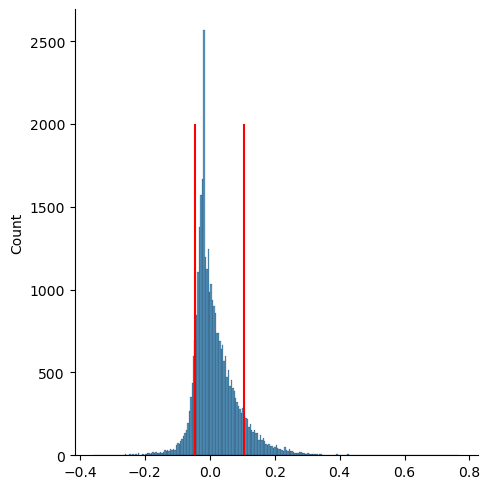

In [229]:
sns.displot(case_corrs.values.flatten())
plt.vlines([lower, upper], ymin=0, ymax=2000, colors=['red', 'red'], )

In [230]:
case_metrics['basal_layer_correlation'] = case_corrs.mean().loc[case_metrics.index.to_list()]
sample_metrics['basal_layer_correlation'] = sample_corrs.mean().loc[sample_metrics.index.to_list()]

In [231]:
case_metrics['positive_passed_threshold'] = (case_corrs > upper).sum().loc[case_metrics.index.to_list()]
sample_metrics['positive_passed_threshold'] = (sample_corrs > upper).sum().loc[sample_metrics.index.to_list()]

In [232]:
case_metrics['negative_passed_threshold'] = (case_corrs < lower).sum().loc[case_metrics.index.to_list()]
sample_metrics['negative_passed_threshold'] = (sample_corrs < lower).sum().loc[sample_metrics.index.to_list()]

In [233]:
case_metrics['positive_passed_threshold_fraction'] = ((case_corrs > upper).sum() / (~pd.isnull(case_corrs)).sum()).loc[case_metrics.index.to_list()]
sample_metrics['positive_passed_threshold_fraction'] = ((sample_corrs > upper).sum() / (~pd.isnull(sample_corrs)).sum()).loc[sample_metrics.index.to_list()]

In [234]:
case_metrics['negative_passed_threshold_fraction'] = ((case_corrs < lower).sum() / (~pd.isnull(case_corrs)).sum()).loc[case_metrics.index.to_list()]
sample_metrics['negative_passed_threshold_fraction'] = ((sample_corrs < lower).sum() / (~pd.isnull(sample_corrs)).sum()).loc[sample_metrics.index.to_list()]

In [235]:
case_metrics['total_count'] = (~pd.isnull(case_corrs)).sum().loc[case_metrics.index.to_list()]
sample_metrics['total_count'] = (~pd.isnull(sample_corrs)).sum().loc[sample_metrics.index.to_list()]

In [236]:
case_metrics.to_csv(output_dir / f'metrics_{mask_type}_caselevel_{disease}.txt', sep='\t')
sample_metrics.to_csv(output_dir / f'metrics_{mask_type}_samplelevel_{disease}.txt', sep='\t')

In [266]:
of_interest = [
    'PLAT',
    'NTN4',
    'SOX9',
    'FAS',
    'MGP',
    'FLRT3',
    'DUOXA1',
    'HMGCS2',
    'UPK1A',
    'TFF1',
    'SERPINA3',
    'CPLX3',
    'TCIM',
    'SORL1',
    'CP',
    'CAMK2N1',
    'GFRA1',
    'FASN',
    'EPHA6',
    'MKI67',
    'MYC',
    'GDF15',
    'CEACAM20',
    'ANPEP',
    'ALDH1A3',
    'KRT8',
    'GLUL',
    'VEGFA',
    'LGALS1',
    'SLC40A1',
    'LMAN1L',
    'FHL2',
    'CD44'
]

In [267]:
case_metrics.loc[[g for g in of_interest if g in case_metrics.index]]

,basal_layer_correlation,positive_passed_threshold,negative_passed_threshold,positive_passed_threshold_fraction,negative_passed_threshold_fraction,total_count
PLAT,0.024817,0,0,0.0,0.0,2
NTN4,0.004565,0,0,0.0,0.0,2
SOX9,0.118588,2,0,1.0,0.0,2
FAS,-0.009442,0,0,0.0,0.0,2
MGP,0.115058,2,0,1.0,0.0,2
FLRT3,0.001562,0,0,0.0,0.0,2
DUOXA1,0.020946,0,0,0.0,0.0,2
HMGCS2,-0.011493,0,1,0.0,0.5,2
UPK1A,0.026388,1,0,0.5,0.0,2
TFF1,0.004754,1,1,0.5,0.5,2


In [268]:
sc_degs = pd.read_csv(f'../data/single-cell/degs/{disease}.txt', sep='\t', index_col=0)
sc_degs

sc_lfc_cut = -.5
keep = sc_degs[sc_degs['logfoldchanges'] < sc_lfc_cut]
keep_genes = set(keep.index.to_list())
len(keep_genes)

16367

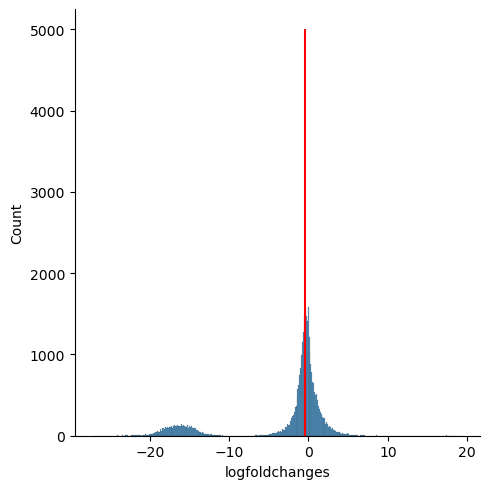

In [269]:

sns.displot(sc_degs['logfoldchanges'])
plt.vlines(sc_lfc_cut, ymin=0, ymax=5000, colors='red', )

In [270]:
sc_degs.loc[of_interest]

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
PLAT,2.640960,0.809092,8.267162e-03,3.129646e-02
NTN4,8.229166,0.408279,1.885215e-16,2.151274e-15
SOX9,-1.545918,0.015157,1.221244e-01,3.587730e-01
FAS,8.287480,3.388672,1.156731e-16,1.337407e-15
MGP,-13.481153,-0.779204,2.019282e-41,5.718621e-40
FLRT3,-6.006580,-2.582533,1.894779e-09,1.430771e-08
DUOXA1,0.578205,0.937919,5.631260e-01,1.000000e+00
HMGCS2,-2.543996,-4.077219,1.095922e-02,4.068934e-02
UPK1A,-0.160331,-1.649531,8.726204e-01,1.000000e+00


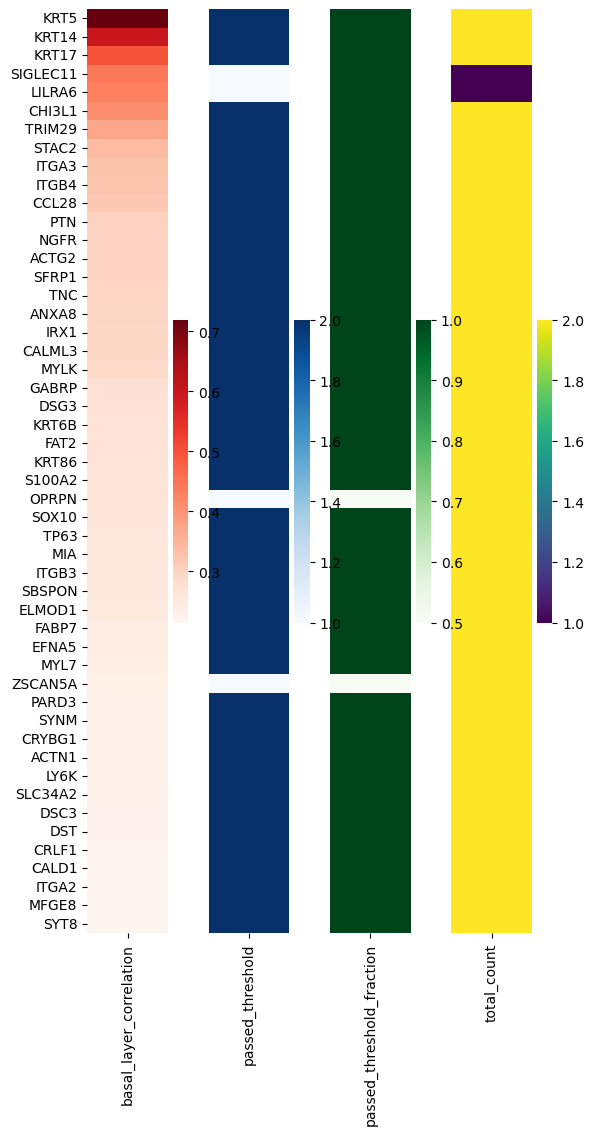

In [271]:
cols = ['basal_layer_correlation', 'positive_passed_threshold', 'positive_passed_threshold_fraction', 'total_count']

source = case_metrics[cols].copy()
source.columns = ['basal_layer_correlation', 'passed_threshold', 'passed_threshold_fraction', 'total_count']
source = source[source['total_count'] >= 1]
source = source[source['passed_threshold_fraction'] >= .5]
source = source.sort_values('basal_layer_correlation', ascending=False)

col_to_cmap = {
    'basal_layer_correlation': 'Reds',
    'passed_threshold': 'Blues',
    'passed_threshold_fraction': 'Greens',
    'total_count': 'viridis'
}


fig, axs = plt.subplots(nrows=1, ncols=source.shape[1], figsize=(6, 12))
for i, (c, ax) in enumerate(zip(source.columns, axs)):
    sns.heatmap(source.iloc[:50][[c]], cmap=col_to_cmap[c], ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    if i != 0:
        ax.set_yticks([])

plt.savefig(output_dir / f'degs_{disease}_t50_pos_noscfilter.svg')
    

In [272]:
source[[g in keep_genes for g in source.index.to_list()]]

,basal_layer_correlation,passed_threshold,passed_threshold_fraction,total_count
SIGLEC11,0.443742,1,1.0,1
CCL28,0.317300,2,1.0,2
LY6K,0.226705,2,1.0,2
PNP,0.204683,2,1.0,2
PLIN2,0.200125,1,0.5,2
...,...,...,...,...
SLC2A10,-0.010208,1,0.5,2
POFUT2,-0.011264,1,0.5,2
MPHOSPH6,-0.020897,1,0.5,2
KRT19,-0.023143,1,0.5,2


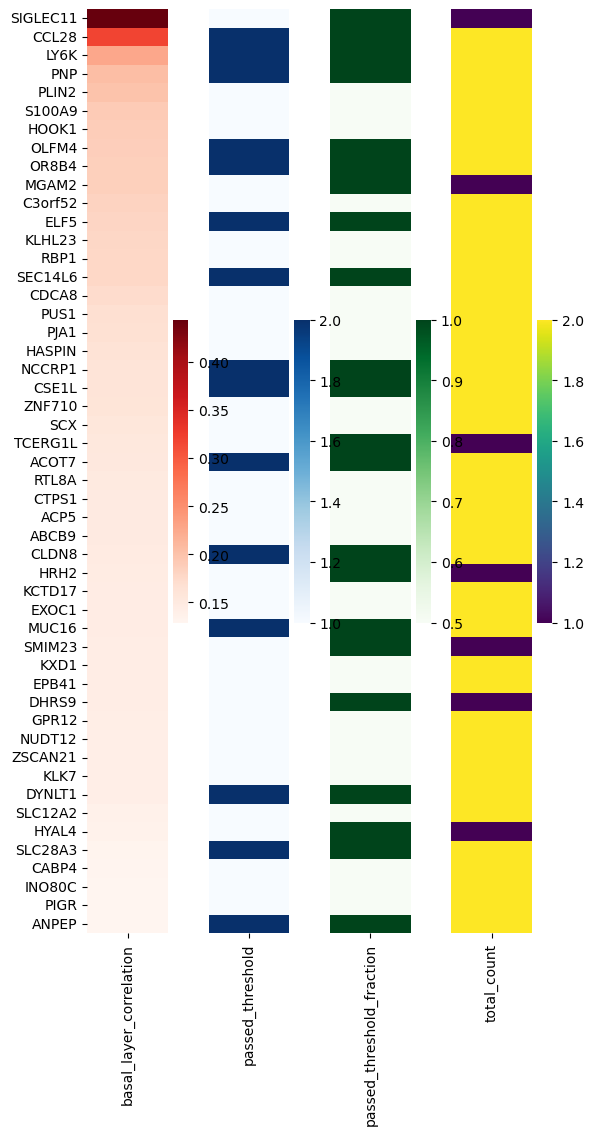

In [273]:
source = source[[g in keep_genes for g in source.index.to_list()]]
fig, axs = plt.subplots(nrows=1, ncols=source.shape[1], figsize=(6, 12))
for i, (c, ax) in enumerate(zip(source.columns, axs)):
    sns.heatmap(source.iloc[:50][[c]], cmap=col_to_cmap[c], ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    if i != 0:
        ax.set_yticks([])

plt.savefig(output_dir / f'degs_{disease}_t50_pos_scfilter.svg')

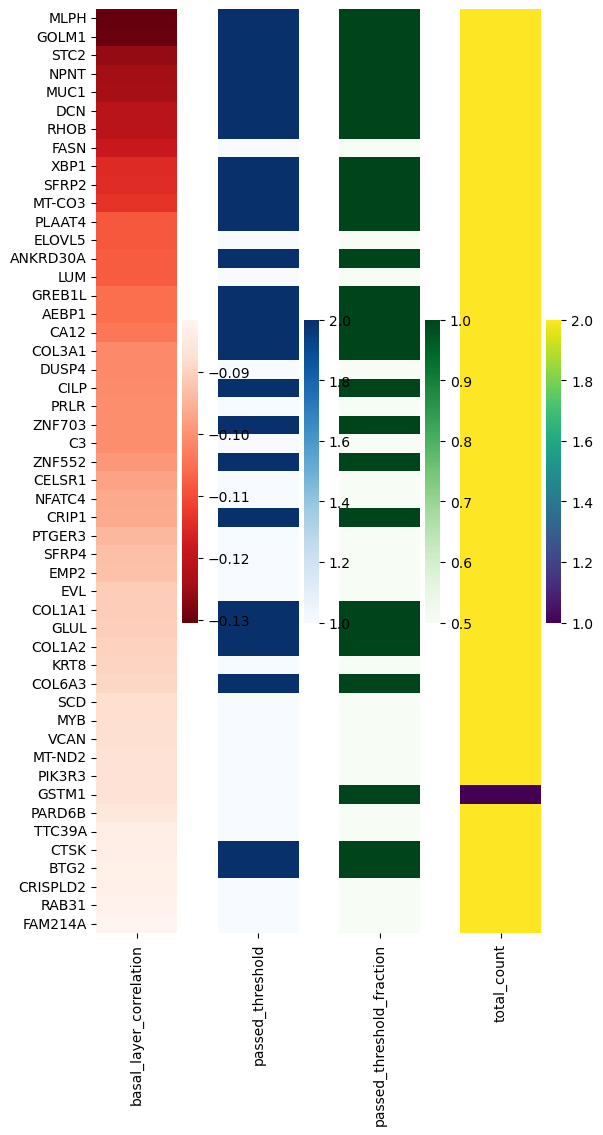

In [274]:
cols = ['basal_layer_correlation', 'negative_passed_threshold', 'negative_passed_threshold_fraction', 'total_count']

source = case_metrics[cols].copy()
source.columns = ['basal_layer_correlation', 'passed_threshold', 'passed_threshold_fraction', 'total_count']
source = source[source['total_count'] >= 1]
source = source[source['passed_threshold_fraction'] >= .5]
source = source.sort_values('basal_layer_correlation', ascending=True)

col_to_cmap = {
    'basal_layer_correlation': 'Reds_r',
    'passed_threshold': 'Blues',
    'passed_threshold_fraction': 'Greens',
    'total_count': 'viridis'
}


fig, axs = plt.subplots(nrows=1, ncols=source.shape[1], figsize=(6, 12))
for i, (c, ax) in enumerate(zip(source.columns, axs)):
    sns.heatmap(source.iloc[:50][[c]], cmap=col_to_cmap[c], ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    if i != 0:
        ax.set_yticks([])

plt.savefig(output_dir / f'degs_{disease}_t50_neg_noscfilter.svg')
    

In [275]:
source[[g in keep_genes for g in source.index.to_list()]]

,basal_layer_correlation,passed_threshold,passed_threshold_fraction,total_count
MLPH,-0.130439,2,1.0,2
GOLM1,-0.130148,2,1.0,2
STC2,-0.125864,2,1.0,2
NPNT,-0.124358,2,1.0,2
MUC1,-0.124053,2,1.0,2
...,...,...,...,...
TMEM198,0.058287,1,0.5,2
PRPF31,0.072721,1,0.5,2
RETREG2,0.079645,1,0.5,2
RAC3,0.087346,1,0.5,2


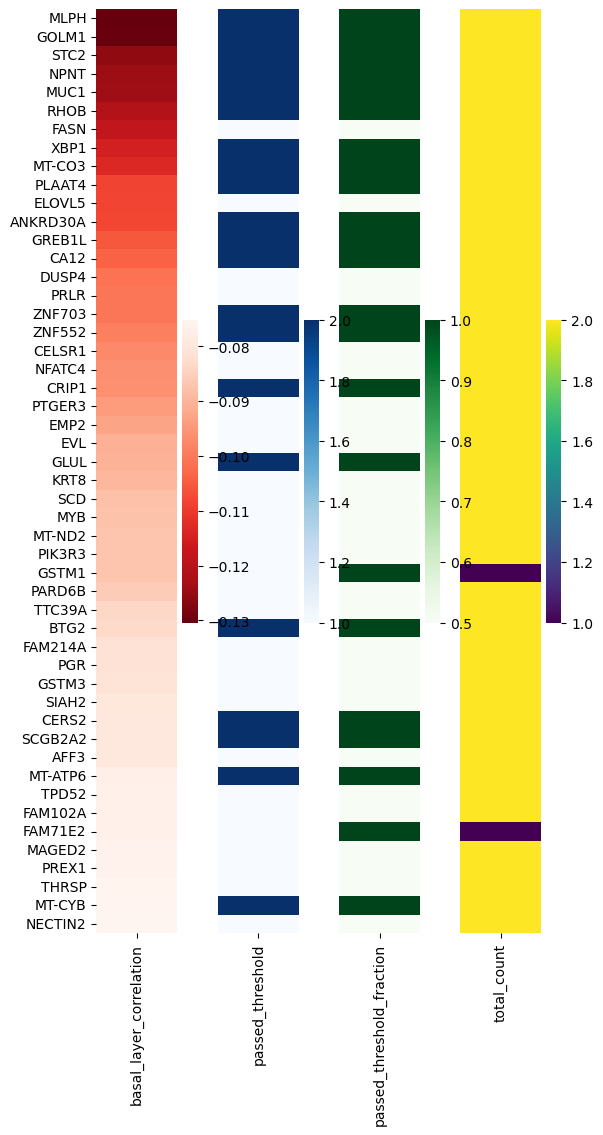

In [276]:

source = source[[g in keep_genes for g in source.index.to_list()]]
fig, axs = plt.subplots(nrows=1, ncols=source.shape[1], figsize=(6, 12))
for i, (c, ax) in enumerate(zip(source.columns, axs)):
    sns.heatmap(source.iloc[:50][[c]], cmap=col_to_cmap[c], ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    if i != 0:
        ax.set_yticks([])

plt.savefig(output_dir / f'degs_{disease}_t50_neg_scfilter.svg')

## visium processing

In [46]:
output_dir = Path('../data/spatial/regions/visium')
output_dir.mkdir(parents=True, exist_ok=True)


In [29]:
directory = Path('../data/spatial/inputs/visium')
fps = [directory / path for path in os.listdir(directory) if '_counts.h5ad' in path]
fps

[PosixPath('../data/spatial/inputs/visium/SP008Z1-Fp1F15U1Bp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT206B1-S1Fc1U1Z1B1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT480B1-S1H3Fs1U1Bp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT308B1-S1H5Fc2U1Z1Bs1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/SP017Z1-Fp1B27Us1_1Bp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT308B1-S1H4Fc2U1Z1Bs1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT397B1-S1H3Fs1U1Bp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT297B1-S1H1Fc2U1Z1Bs1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT206B1-S1Fc1U2Z1B1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/SP017Z1-Fp1B27Us1_16Bp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT206B1-S1Fc1U4Z1B1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/SP060Z1-Fp1U1Bp1_counts.h5ad'),
 PosixPath('../data/spatial/inputs/visium/HT308B1-S1H1Fc2U1Z1

In [30]:
for fp in fps:
    adata = sc.read_h5ad(fp)
    print(adata.shape)
    print(fp, set(adata.obs['label']))

(4731, 17943)
../data/spatial/inputs/visium/SP008Z1-Fp1F15U1Bp1_counts.h5ad {'GP 2', nan, 'GP 1', 'GP 5', 'GP 4', 'GP 3'}
(3651, 36601)
../data/spatial/inputs/visium/HT206B1-S1Fc1U1Z1B1_counts.h5ad {'IDC 2', 'DCIS 2', 'IDC 6', 'IDC 4', 'IDC 5', 'Normal 4', 'DCIS 7', 'DCIS 1', 'Normal 3', 'DCIS 8', 'Normal 5', 'DCIS 3', 'DCIS 4', 'Normal 2', 'Normal 1', 'DCIS 0', 'IDC 1', 'DCIS 5', 'DCIS 6', 'IDC 9', nan}
(1445, 17943)
../data/spatial/inputs/visium/HT480B1-S1H3Fs1U1Bp1_counts.h5ad {'DCIS 4', 'DCIS 5', 'DCIS 6', 'DCIS-to-IDC 1', 'DCIS 9', 'DCIS 2', 'DCIS 8', nan, 'DCIS 10', 'IDC 1', 'DCIS 7', 'DCIS 3', 'DCIS 1', 'DCIS 11'}
(4568, 36601)
../data/spatial/inputs/visium/HT308B1-S1H5Fc2U1Z1Bs1_counts.h5ad {'DCIS 3', 'DCIS 4', 'IDC 2', 'DCIS 6', 'DCIS 2', 'IDC 4', 'IDC 5', nan, 'IDC 1', 'IDC 3', 'DCIS 5', 'DCIS 1'}
(4135, 17943)
../data/spatial/inputs/visium/SP017Z1-Fp1B27Us1_1Bp1_counts.h5ad {'GP 1', 'Normal 2', 'GP 2', 'Normal 1', 'Normal 5', nan, 'Normal 4', 'Normal 3', 'GP 5', 'GP 4', 'GP 

In [31]:
def process_adata(adata):
    sc.pp.filter_cells(adata, min_counts=10)
    sc.pp.filter_genes(adata, min_cells=5)
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    return adata

def sum_counts_by_label(adata, layer='counts', label_col='label'):
    """
    Note is actually mean not sum
    """
    # Drop NaN labels
    valid_mask = adata.obs[label_col].notna().values
    labels = adata.obs[label_col][valid_mask]

#     X = adata.layers[layer] if layer in adata.layers else adata.X
    X = adata.X
    if sparse.issparse(X):
        X = X.tocsr()[valid_mask]
    else:
        X = X[valid_mask]

    labels = labels.values
    unique_labels = np.unique(labels)
    gene_names = adata.var_names.to_numpy()

    result = np.zeros((len(unique_labels), X.shape[1]), dtype=np.float32)
    counts = np.zeros(len(unique_labels), dtype=int)
    label_to_index = {label: i for i, label in enumerate(unique_labels)}

    for i, label in enumerate(labels):
        row_idx = label_to_index[label]
        row = X[i]
        if sparse.issparse(row):
            row = row.toarray().ravel()
        result[row_idx] += row
        counts[row_idx] += 1

    # Divide by cell counts to get means
    result = result / counts[:, np.newaxis]

    return pd.DataFrame(result, index=unique_labels, columns=gene_names)



In [32]:
abundances = []
for fp in fps:
    sid = str(fp).split('/')[-1].replace('_counts.h5ad', '')
    print(sid)
    adata = sc.read_h5ad(fp)
    adata = process_adata(adata)
    result = sum_counts_by_label(adata)
    result.index = [f'{sid}_{x}' for x in result.index.to_list()]
    abundances.append(result)
abundances = pd.concat(abundances)
abundances

SP008Z1-Fp1F15U1Bp1
HT206B1-S1Fc1U1Z1B1
HT480B1-S1H3Fs1U1Bp1
HT308B1-S1H5Fc2U1Z1Bs1
SP017Z1-Fp1B27Us1_1Bp1
HT308B1-S1H4Fc2U1Z1Bs1
HT397B1-S1H3Fs1U1Bp1
HT297B1-S1H1Fc2U1Z1Bs1
HT206B1-S1Fc1U2Z1B1
SP017Z1-Fp1B27Us1_16Bp1
HT206B1-S1Fc1U4Z1B1
SP060Z1-Fp1U1Bp1
HT308B1-S1H1Fc2U1Z1Bs1
HT397B1-S1H3A1U21Bp1
HT206B1-S1Fc1U3Z1B1
HT480B1-S1H1Fs1U2Bp1
HT480B1-S1H1Fs1U1Bp1
HT486B1-S1H1Fs1U1Bp1
HT397B1-S1H3A1U1Bp1
HT339B1-S1H3Fc2U1Z1Bs1
HT206B1-S1Fc1U5Z1B1
HT397B1-S1H3A1U41Bp1
HT339B1-S1H3Fc2U2Bs2
HT397B1-S1H2Fs4U1Bp1
HT397B1-S1H3A1U61Bp1
HT425B1-S1H2Fs1U2Bp1
HT323B1-S1H1Fc2U1Z1Bs1
HT486B1-S1H1Fs1U2Bp1


,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,C1orf159,TTLL10,...,HDGFL1,ADGRA1,C11orf97,CFAP97D2,RNASE11,KRTAP3-1,KRTAP10-6,KRTAP12-4,BMP15,TBX22
SP008Z1-Fp1F15U1Bp1_GP 1,0.000000,0.126962,0.000000,0.000000,0.0,0.491102,0.149917,0.162103,0.073107,0.067292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 2,0.000000,0.082840,0.000000,0.077155,0.0,0.386109,0.059747,0.314323,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 3,0.000000,0.242435,0.000000,0.000000,0.0,0.085242,0.118096,0.188203,0.048012,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 4,0.000000,0.129863,0.000000,0.000000,0.0,0.363098,0.028488,0.210103,0.131041,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 5,0.059534,0.057436,0.000000,0.000000,0.0,0.465554,0.030375,0.107810,0.038594,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HT486B1-S1H1Fs1U2Bp1_IDC 1,0.101937,0.678298,0.094093,0.215386,NaN,0.741388,1.079172,1.663612,0.489532,0.221305,...,0.004683,0.012694,0.0,0.000000,0.000000,0.000000,0.0,0.003685,0.0,0.0
HT486B1-S1H1Fs1U2Bp1_IDC 2,0.050978,0.683741,0.100479,0.166350,NaN,0.952778,1.505291,1.765127,0.335448,0.279647,...,0.000000,0.000000,0.0,0.049501,0.026462,0.000000,0.0,0.000000,0.0,0.0
HT486B1-S1H1Fs1U2Bp1_IDC 3,0.000000,0.522180,0.088945,0.265734,NaN,0.745285,0.341220,1.906358,0.280394,0.185112,...,0.000000,0.000000,0.0,0.000000,0.000000,0.050392,0.0,0.000000,0.0,0.0
HT486B1-S1H1Fs1U2Bp1_IDC 4,0.034273,0.577211,0.034273,0.140626,NaN,0.730341,0.552521,1.555730,0.395830,0.207857,...,0.000000,0.000000,0.0,0.000000,0.000000,0.034273,0.0,0.000000,0.0,0.0


In [33]:
abundances.index.name = 'region_id'
abundances.to_csv(output_dir / f'region_abundances.txt', sep='\t')

## visium analysis

In [53]:
level = 'sample'

In [54]:
abundances = pd.read_csv(output_dir / f'region_abundances.txt', sep='\t', index_col='region_id')
abundances

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,C1orf159,TTLL10,...,HDGFL1,ADGRA1,C11orf97,CFAP97D2,RNASE11,KRTAP3-1,KRTAP10-6,KRTAP12-4,BMP15,TBX22
region_id,,,,,,,,,,,,,,,,,,,,,
SP008Z1-Fp1F15U1Bp1_GP 1,0.000000,0.126962,0.000000,0.000000,0.0,0.491102,0.149917,0.162103,0.073107,0.067292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 2,0.000000,0.082840,0.000000,0.077155,0.0,0.386109,0.059747,0.314323,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 3,0.000000,0.242435,0.000000,0.000000,0.0,0.085242,0.118096,0.188203,0.048012,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 4,0.000000,0.129863,0.000000,0.000000,0.0,0.363098,0.028488,0.210103,0.131041,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP008Z1-Fp1F15U1Bp1_GP 5,0.059534,0.057436,0.000000,0.000000,0.0,0.465554,0.030375,0.107810,0.038594,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HT486B1-S1H1Fs1U2Bp1_IDC 1,0.101937,0.678298,0.094093,0.215386,NaN,0.741388,1.079172,1.663612,0.489532,0.221305,...,0.004683,0.012694,0.0,0.000000,0.000000,0.000000,0.0,0.003685,0.0,0.0
HT486B1-S1H1Fs1U2Bp1_IDC 2,0.050978,0.683741,0.100479,0.166350,NaN,0.952778,1.505291,1.765127,0.335448,0.279647,...,0.000000,0.000000,0.0,0.049501,0.026462,0.000000,0.0,0.000000,0.0,0.0
HT486B1-S1H1Fs1U2Bp1_IDC 3,0.000000,0.522180,0.088945,0.265734,NaN,0.745285,0.341220,1.906358,0.280394,0.185112,...,0.000000,0.000000,0.0,0.000000,0.000000,0.050392,0.0,0.000000,0.0,0.0


In [55]:
set([x.split('-')[0] for x in abundances.index])

{'HT206B1',
 'HT297B1',
 'HT308B1',
 'HT323B1',
 'HT339B1',
 'HT397B1',
 'HT425B1',
 'HT480B1',
 'HT486B1',
 'SP008Z1',
 'SP017Z1',
 'SP060Z1'}

In [56]:
abundances['case'] = [x.split('-')[0] for x in abundances.index]
abundances['disease'] = ['breast' if 'B1' in x else 'prostate' for x in abundances['case']]
abundances['sample'] = [x.split('_')[0] for x in abundances.index]
abundances['type'] = [x.split('_')[-1].split(' ')[0] for x in abundances.index]
abundances['idx'] = [x.split(' ')[-1] for x in abundances.index]
abundances

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,C1orf159,TTLL10,...,KRTAP3-1,KRTAP10-6,KRTAP12-4,BMP15,TBX22,case,disease,sample,type,idx
region_id,,,,,,,,,,,,,,,,,,,,,
SP008Z1-Fp1F15U1Bp1_GP 1,0.000000,0.126962,0.000000,0.000000,0.0,0.491102,0.149917,0.162103,0.073107,0.067292,...,NaN,NaN,NaN,NaN,NaN,SP008Z1,prostate,SP008Z1-Fp1F15U1Bp1,GP,1
SP008Z1-Fp1F15U1Bp1_GP 2,0.000000,0.082840,0.000000,0.077155,0.0,0.386109,0.059747,0.314323,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,SP008Z1,prostate,SP008Z1-Fp1F15U1Bp1,GP,2
SP008Z1-Fp1F15U1Bp1_GP 3,0.000000,0.242435,0.000000,0.000000,0.0,0.085242,0.118096,0.188203,0.048012,0.000000,...,NaN,NaN,NaN,NaN,NaN,SP008Z1,prostate,SP008Z1-Fp1F15U1Bp1,GP,3
SP008Z1-Fp1F15U1Bp1_GP 4,0.000000,0.129863,0.000000,0.000000,0.0,0.363098,0.028488,0.210103,0.131041,0.000000,...,NaN,NaN,NaN,NaN,NaN,SP008Z1,prostate,SP008Z1-Fp1F15U1Bp1,GP,4
SP008Z1-Fp1F15U1Bp1_GP 5,0.059534,0.057436,0.000000,0.000000,0.0,0.465554,0.030375,0.107810,0.038594,0.000000,...,NaN,NaN,NaN,NaN,NaN,SP008Z1,prostate,SP008Z1-Fp1F15U1Bp1,GP,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HT486B1-S1H1Fs1U2Bp1_IDC 1,0.101937,0.678298,0.094093,0.215386,NaN,0.741388,1.079172,1.663612,0.489532,0.221305,...,0.000000,0.0,0.003685,0.0,0.0,HT486B1,breast,HT486B1-S1H1Fs1U2Bp1,IDC,1
HT486B1-S1H1Fs1U2Bp1_IDC 2,0.050978,0.683741,0.100479,0.166350,NaN,0.952778,1.505291,1.765127,0.335448,0.279647,...,0.000000,0.0,0.000000,0.0,0.0,HT486B1,breast,HT486B1-S1H1Fs1U2Bp1,IDC,2
HT486B1-S1H1Fs1U2Bp1_IDC 3,0.000000,0.522180,0.088945,0.265734,NaN,0.745285,0.341220,1.906358,0.280394,0.185112,...,0.050392,0.0,0.000000,0.0,0.0,HT486B1,breast,HT486B1-S1H1Fs1U2Bp1,IDC,3


In [57]:
import numpy as np
from scipy.stats import spearmanr, ttest_ind

def ttest_per_column(arr1: np.ndarray, arr2: np.ndarray, equal_var: bool = False):
    if arr1.shape[1] != arr2.shape[1]:
        raise ValueError("Arrays must have the same number of columns")

    tstats = np.empty(arr1.shape[1])
    pvals = np.empty(arr1.shape[1])

    for i in range(arr1.shape[1]):
        a, b = arr1[:, i], arr2[:, i]
        a = a[~pd.isnull(a)].astype(float)
        b = b[~pd.isnull(b)].astype(float)
#         print(a.dtype, b.dtype)
        
        if len(a) > 1 and len(b) > 1:
#             print('a', a, 'b', b)
            t, p = ttest_ind(a, b, equal_var=equal_var, nan_policy='omit')
            tstats[i] = t
            pvals[i] = p
        else:
            tstats[i] = np.nan
            pvals[i] = np.nan

    return tstats, pvals


def get_corr_df(abundances, f1='DCIS', f2='IDC', level='case'):
    corr_rows, pval_rows, ids = [], [], []
    for case in set(abundances[level]):
        f = abundances[abundances[level]==case]
        xs = f[f['type']==f1].iloc[:, :-5].values
        ys = f[f['type']==f2].iloc[:, :-5].values

        if xs.shape[0] and ys.shape[0]:
            print(case)
            corrs, pvals = ttest_per_column(xs, ys)
            corr_rows.append(corrs)
            pval_rows.append(pvals)
            ids.append(case)
        
    stat_df = pd.DataFrame(data=np.stack(corr_rows), columns=abundances.columns[:-5], index=ids)
    pval_df = pd.DataFrame(data=np.stack(pval_rows), columns=abundances.columns[:-5], index=ids)
    
    return stat_df, pval_df

In [58]:
stat_df, pval_df = get_corr_df(abundances, f1='DCIS', f2='IDC')
stat_df

HT206B1-S1Fc1U2Z1B1
HT206B1-S1Fc1U4Z1B1
HT206B1-S1Fc1U1Z1B1
HT323B1-S1H1Fc2U1Z1Bs1
HT397B1-S1H3A1U21Bp1
HT486B1-S1H1Fs1U1Bp1
HT480B1-S1H1Fs1U2Bp1
HT206B1-S1Fc1U3Z1B1
HT397B1-S1H2Fs4U1Bp1
HT308B1-S1H4Fc2U1Z1Bs1
HT308B1-S1H5Fc2U1Z1Bs1
HT480B1-S1H3Fs1U1Bp1
HT397B1-S1H3Fs1U1Bp1
HT308B1-S1H1Fc2U1Z1Bs1
HT480B1-S1H1Fs1U1Bp1
HT397B1-S1H3A1U1Bp1
HT206B1-S1Fc1U5Z1B1
HT297B1-S1H1Fc2U1Z1Bs1


,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,C1orf159,TTLL10,...,HDGFL1,ADGRA1,C11orf97,CFAP97D2,RNASE11,KRTAP3-1,KRTAP10-6,KRTAP12-4,BMP15,TBX22
HT206B1-S1Fc1U2Z1B1,0.710318,0.339572,-0.563136,0.701400,NaN,-0.623785,-0.158511,-1.934917,0.282960,-1.087722,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT206B1-S1Fc1U4Z1B1,-0.161510,0.478249,1.038886,-0.877248,1.000000,-1.135881,-0.414375,-1.074514,-0.774918,-1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT206B1-S1Fc1U1Z1B1,0.021816,-1.958272,-1.542669,-0.554473,1.000000,-1.579021,-1.573082,0.396833,-2.144108,-1.110437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT323B1-S1H1Fc2U1Z1Bs1,-0.519143,0.524308,0.734819,1.690390,0.356473,-0.525549,-2.303670,0.381343,1.417130,1.549534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT397B1-S1H3A1U21Bp1,-0.116651,-0.321933,-0.468957,-2.324383,NaN,0.715321,-1.285654,0.010205,-0.276240,0.724957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT486B1-S1H1Fs1U1Bp1,NaN,1.567883,0.759359,0.912318,NaN,1.672824,-1.371531,1.373717,-0.298611,1.465062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT480B1-S1H1Fs1U2Bp1,-0.410397,0.253624,-0.858671,0.675085,1.000000,-2.032925,0.046243,0.311807,-1.299142,-2.032050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT206B1-S1Fc1U3Z1B1,-0.435607,0.751064,-0.052750,0.276920,1.000000,-0.632850,-0.933748,-1.707799,-1.023137,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT397B1-S1H2Fs4U1Bp1,0.561408,0.687081,0.502713,-0.729037,NaN,1.078320,3.271862,1.892495,0.168377,1.439624,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT308B1-S1H4Fc2U1Z1Bs1,0.809473,0.905881,1.671769,-1.810450,0.513257,-0.788304,0.272030,-0.627286,0.569280,0.839011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
pval_df

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,C1orf159,TTLL10,...,HDGFL1,ADGRA1,C11orf97,CFAP97D2,RNASE11,KRTAP3-1,KRTAP10-6,KRTAP12-4,BMP15,TBX22
HT206B1-S1Fc1U2Z1B1,0.500348,0.760517,0.615085,0.498547,NaN,0.591918,0.882194,0.153259,0.789556,0.390337,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT206B1-S1Fc1U4Z1B1,0.882132,0.673698,0.356704,0.452740,0.335561,0.355002,0.714876,0.379862,0.479652,0.422650,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT206B1-S1Fc1U1Z1B1,0.982974,0.072914,0.146966,0.590829,0.346594,0.152589,0.141299,0.698271,0.053896,0.317338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT323B1-S1H1Fc2U1Z1Bs1,0.613388,0.620554,0.477578,0.118783,0.729796,0.611550,0.085499,0.709766,0.184739,0.151370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT397B1-S1H3A1U21Bp1,0.910287,0.758945,0.652498,0.076640,NaN,0.503340,0.258708,0.992138,0.789486,0.504339,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT486B1-S1H1Fs1U1Bp1,NaN,0.150849,0.464013,0.380099,NaN,0.125504,0.235382,0.236686,0.781709,0.176945,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT480B1-S1H1Fs1U2Bp1,0.703681,0.810147,0.431636,0.536632,0.373901,0.098600,0.969005,0.770756,0.250781,0.158116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT206B1-S1Fc1U3Z1B1,0.698755,0.523257,0.961342,0.801913,0.337049,0.581523,0.440983,0.179537,0.359344,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT397B1-S1H2Fs4U1Bp1,0.580429,0.554903,0.626166,0.535720,NaN,0.385944,0.003977,0.146591,0.881071,0.164621,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT308B1-S1H4Fc2U1Z1Bs1,0.425644,0.372905,0.105752,0.082761,0.612373,0.437245,0.787644,0.535581,0.573706,0.410505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
stat_df.index.name = 'case'
stat_df.to_csv(output_dir / 'ttest_stat_caselevel_breast.txt', sep='\t')

pval_df.index.name = 'case'
pval_df.to_csv(output_dir / 'ttest_pval_caselevel_breast.txt', sep='\t')

In [54]:
stat_df, pval_df = get_corr_df(abundances, f1='Normal', f2='GP')

stat_df.index.name = 'case'
stat_df.to_csv(output_dir / 'ttest_stat_caselevel_prostate.txt', sep='\t')

pval_df.index.name = 'case'
pval_df.to_csv(output_dir / 'ttest_pval_caselevel_prostate.txt', sep='\t')

HT486B1
HT323B1
HT206B1
HT339B1
HT397B1
HT425B1
HT480B1
HT308B1
SP060Z1
HT297B1
SP008Z1
SP017Z1


In [55]:
stat_df

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,C1orf159,TTLL10,...,HDGFL1,ADGRA1,C11orf97,CFAP97D2,RNASE11,KRTAP3-1,KRTAP10-6,KRTAP12-4,BMP15,TBX22
case,,,,,,,,,,,,,,,,,,,,,
SP060Z1,-1.000000,-0.574539,NaN,-1.309172,NaN,-0.294579,0.174354,-5.974367,-1.274838,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP017Z1,0.265336,-1.822604,0.94424,0.867068,NaN,-0.908182,2.197151,0.488232,-0.420545,-1.625947,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


section level

In [59]:
stat_df, pval_df = get_corr_df(abundances, f1='DCIS', f2='IDC', level='sid')


stat_df.index.name = 'sid'
stat_df.to_csv(output_dir / 'ttest_stat_sectionlevel_breast.txt', sep='\t')

pval_df.index.name = 'sid'
pval_df.to_csv(output_dir / 'ttest_pval_sectionlevel_breast.txt', sep='\t')

HT308B1-S1H5Fc2U1Z1Bs1
HT297B1-S1H1Fc2U1Z1Bs1
HT308B1-S1H4Fc2U1Z1Bs1
HT206B1-S1Fc1U1Z1B1
HT206B1-S1Fc1U4Z1B1
HT308B1-S1H1Fc2U1Z1Bs1
HT480B1-S1H1Fs1U2Bp1
HT397B1-S1H3A1U61Bp1
HT206B1-S1Fc1U3Z1B1
HT339B1-S1H3Fc2U2Bs2
HT425B1-S1H2Fs1U2Bp1
HT397B1-S1H3A1U41Bp1
SP060Z1-Fp1U1Bp1
HT486B1-S1H1Fs1U2Bp1
HT397B1-S1H2Fs4U1Bp1
HT206B1-S1Fc1U5Z1B1
SP017Z1-Fp1B27Us1
HT480B1-S1H3Fs1U1Bp1
HT486B1-S1H1Fs1U1Bp1
HT397B1-S1H3Fs1U1Bp1
HT206B1-S1Fc1U2Z1B1
HT339B1-S1H3Fc2U1Z1Bs1
HT323B1-S1H1Fc2U1Z1Bs1
HT397B1-S1H3A1U1Bp1
HT397B1-S1H3A1U21Bp1
SP008Z1-Fp1F15U1Bp1
HT480B1-S1H1Fs1U1Bp1


In [60]:
stat_df, pval_df = get_corr_df(abundances, f1='Normal', f2='GP', level='sid')


stat_df.index.name = 'sid'
stat_df.to_csv(output_dir / 'ttest_stat_sectionlevel_prostate.txt', sep='\t')

pval_df.index.name = 'sid'
pval_df.to_csv(output_dir / 'ttest_pval_sectionlevel_prostate.txt', sep='\t')

HT308B1-S1H5Fc2U1Z1Bs1
HT297B1-S1H1Fc2U1Z1Bs1
HT308B1-S1H4Fc2U1Z1Bs1
HT206B1-S1Fc1U1Z1B1
HT206B1-S1Fc1U4Z1B1
HT308B1-S1H1Fc2U1Z1Bs1
HT480B1-S1H1Fs1U2Bp1
HT397B1-S1H3A1U61Bp1
HT206B1-S1Fc1U3Z1B1
HT339B1-S1H3Fc2U2Bs2
HT425B1-S1H2Fs1U2Bp1
HT397B1-S1H3A1U41Bp1
SP060Z1-Fp1U1Bp1
HT486B1-S1H1Fs1U2Bp1
HT397B1-S1H2Fs4U1Bp1
HT206B1-S1Fc1U5Z1B1
SP017Z1-Fp1B27Us1
HT480B1-S1H3Fs1U1Bp1
HT486B1-S1H1Fs1U1Bp1
HT397B1-S1H3Fs1U1Bp1
HT206B1-S1Fc1U2Z1B1
HT339B1-S1H3Fc2U1Z1Bs1
HT323B1-S1H1Fc2U1Z1Bs1
HT397B1-S1H3A1U1Bp1
HT397B1-S1H3A1U21Bp1
SP008Z1-Fp1F15U1Bp1
HT480B1-S1H1Fs1U1Bp1


disease level

In [61]:
stat_df, pval_df = get_corr_df(abundances, f1='DCIS', f2='IDC', level='disease')


stat_df.index.name = 'disease'
stat_df.to_csv(output_dir / 'ttest_stat_diseaselevel_breast.txt', sep='\t')

pval_df.index.name = 'disease'
pval_df.to_csv(output_dir / 'ttest_pval_diseaselevel_breast.txt', sep='\t')

breast
prostate


In [62]:
stat_df, pval_df = get_corr_df(abundances, f1='Normal', f2='GP', level='disease')


stat_df.index.name = 'disease'
stat_df.to_csv(output_dir / 'ttest_stat_diseaselevel_prostate.txt', sep='\t')

pval_df.index.name = 'disease'
pval_df.to_csv(output_dir / 'ttest_pval_diseaselevel_prostate.txt', sep='\t')

breast
prostate
